In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import xarray as xr
import numpy as np
from natsort import natsorted
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [3]:
import sys
original_path = os.getcwd()  
os.chdir(original_path)
function_path = './functions/'
sys.path.append(function_path)
from smoothing_function import *
from model_analysis_function import *
from analysis_function import *
from Plot_function import *
from ar6_area_weighted_cont_global import *
# from obs_function import *

## Constrain global temperature
### Load global data

In [4]:
path = '/Users/tongli1997/Library/CloudStorage/OneDrive-UniversityofVictoria/Codes_run_on_local/Global_regional_attribution/Augest_Sep_2025/saved_data/'

file_name = '0.CRUT5&HadCRUT5.Tas.anomalies.AR6.continental.LSAT.GSAT.1850-2024.nc'
obs_all= xr.open_dataarray(path + file_name) 

file_name = '0.HadCRUT5.200runs.nan-masked.to.CRUT5.Tas.anomalies.AR6.continental.LSAT.GSAT.46regions_175years.nc'
obs_200runs_all = xr.open_dataarray(path + file_name) 

file_name = '0.Smoothed.His-ALL-nat-ant-ghg-oa.nan-masked.Tas.anomalies.AR6.continental.LSAT.GSAT.1850-2025.nc'
mod_all = xr.open_dataarray(path + file_name) 

file_name = '0.Large_ensembles.320runs.nan-masked.full.time.series.Tas.anomalies.AR6.continental.LSAT.GSAT.1850-2025.nc'
ln_mod_all = xr.open_dataarray(path + file_name) 


file_name = '0.pseudo-model_45.run1-3.Tas.anomalies.AR6.continental.LSAT.GSAT.46regions_176years.1850-2025.nc'
mod_45_pseudo = xr.open_dataarray(path + file_name) 

file_name = '0.Smoothed.His-Fu.24mod.1850-2100.non.masked.Tas.anomalies.AR6.continental.global.nc'
mod_all_his_fu= xr.open_dataarray(path + file_name).expand_dims(forcing = ['ALL'])

In [5]:
file_path = '/Users/tongli1997/Library/CloudStorage/OneDrive-UniversityofVictoria/Codes_run_on_local/July_2025_Canada_paper/CA_Earth_future_review/saved_data_from_server/'

### Large ensemble here for estimate obs IV Cov
file_name = '0.5.large_ensembles.320runs.weighted_8regions.Ca.Sub-regions.GSAT.Anom.1850-2100.nc'
ln_8reg = xr.open_dataarray(file_path + file_name)

ln_gsat = ln_8reg.sel(Region = 'GSAT').sel(time = 2025)
ln_gsat

<xarray.DataArray (pseudo: 320)> Size: 3kB
[320 values with dtype=float64]
Coordinates:
    time        int64 8B 2025
    Region      <U16 64B 'GSAT'
  * pseudo      (pseudo) <U23 29kB 'CESM2_run_1' ... 'MPI-ESM1-2-LR_r9i1p1f1'
    model_name  (pseudo) <U13 17kB ...

In [6]:
# Convert ln_gsat to the same dimension convention as ln_mod_all
ln_gsat_2025 = (
    ln_gsat
    .drop_vars(["time", "Region"], errors="ignore")
    .rename(pseudo="model_run")
)

# Check that both arrays contain exactly the same model runs
missing_runs = set(ln_mod_all.model_run.values) - set(
    ln_gsat_2025.model_run.values
)
extra_runs = set(ln_gsat_2025.model_run.values) - set(
    ln_mod_all.model_run.values
)

if missing_runs or extra_runs:
    raise ValueError(
        f"Model-run mismatch: "
        f"{len(missing_runs)} missing and {len(extra_runs)} extra"
    )

# Reorder ln_gsat to exactly match ln_mod_all
ln_gsat_2025 = ln_gsat_2025.sel(
    model_run=ln_mod_all.model_run
)

# Add 2025 to the complete regional array
ln_mod_all_updated = ln_mod_all.reindex(
    year=[*ln_mod_all.year.values, 2025]
)

# Populate only GSAT in 2025
ln_mod_all_updated.loc[
    dict(year=2025, region="GSAT")
] = ln_gsat_2025.values

#### Read the new updated GSAT HadCRUT5

In [7]:
path = './saved_data/'

file_name = 'HadCRUT.5.1.0.0.analysis.ensemble_series.global.annual.nc'
had_gsat_200runs = xr.open_dataset(path + file_name)['tas']
had_gsat_mean = had_gsat_200runs.mean('realization')


### combine ths GSAT 

In [8]:
analysis_years = np.arange(1850, 2026)

# Convert HadCRUT timestamps to the integer years used by obs_all.
had_gsat_mean_by_year = (
    had_gsat_mean
    .assign_coords(time=had_gsat_mean.time.dt.year)
    .rename(time="year")
    .sel(year=analysis_years)
    .drop_vars(["latitude", "longitude"], errors="ignore")
)

if not np.array_equal(had_gsat_mean_by_year.year.values, analysis_years):
    raise ValueError("HadCRUT mean does not contain every year from 1850 to 2025")

# Extend through 2025 and replace the entire GSAT series.
obs_all_updated = obs_all.reindex(year=analysis_years)
obs_all_updated.loc[dict(region="GSAT")] = had_gsat_mean_by_year.values

# Confirm GSAT was replaced and historical non-GSAT data were untouched.
np.testing.assert_allclose(
    obs_all_updated.sel(region="GSAT").values,
    had_gsat_mean_by_year.values,
    equal_nan=True,
)
xr.testing.assert_equal(
    obs_all_updated.sel(year=obs_all.year).drop_sel(region="GSAT"),
    obs_all.drop_sel(region="GSAT"),
)

obs_gsat = obs_all_updated.sel(region="GSAT")

In [9]:
# Convert HadCRUT dimensions to the conventions used by obs_200runs_all.
had_gsat_200runs_by_year = (
    had_gsat_200runs
    .assign_coords(time=had_gsat_200runs.time.dt.year)
    .rename({"time": "year", "realization": "runs"})
    .sel(year=analysis_years)
    .drop_vars(["latitude", "longitude"], errors="ignore")
    .transpose("runs", "year")
)

# Align members by realization label before adopting the obs run indices.
expected_realizations = obs_200runs_all.realization.values
missing_realizations = set(expected_realizations) - set(had_gsat_200runs_by_year.runs.values)
extra_realizations = set(had_gsat_200runs_by_year.runs.values) - set(expected_realizations)
if missing_realizations or extra_realizations:
    raise ValueError(
        f"Realization mismatch: {len(missing_realizations)} missing and "
        f"{len(extra_realizations)} extra"
    )

had_gsat_200runs_by_year = (
    had_gsat_200runs_by_year
    .sel(runs=expected_realizations)
    .assign_coords(
        runs=obs_200runs_all.runs.values,
        realization=("runs", expected_realizations),
    )
)

if not np.array_equal(had_gsat_200runs_by_year.year.values, analysis_years):
    raise ValueError("HadCRUT ensemble does not contain every year from 1850 to 2025")

# Extend through 2025 and replace the entire GSAT series for all runs.
obs_200runs_updated = obs_200runs_all.reindex(year=analysis_years)
obs_200runs_updated.loc[dict(region="GSAT")] = had_gsat_200runs_by_year.values

# Confirm GSAT was replaced and historical non-GSAT data were untouched.
np.testing.assert_allclose(
    obs_200runs_updated.sel(region="GSAT").values,
    had_gsat_200runs_by_year.values,
    equal_nan=True,
)
xr.testing.assert_equal(
    obs_200runs_updated.sel(year=obs_200runs_all.year).drop_sel(region="GSAT"),
    obs_200runs_all.drop_sel(region="GSAT"),
)

obs_gsat_200runs = obs_200runs_updated.sel(region="GSAT")
obs_200runs_updated


<xarray.DataArray 'ensemble_ar6' (runs: 200, year: 176, region: 55)> Size: 15MB
array([[[-0.21135584, -1.47351107,         nan, ...,         nan,
         -0.53454095, -0.40542541],
        [ 0.51922772, -0.22351107,         nan, ...,         nan,
         -0.27112995, -0.17599079],
        [ 0.34741718, -1.01517774,         nan, ...,         nan,
         -0.39729961, -0.08996581],
        ...,
        [ 1.00480731,  2.20214072,  2.29666675, ...,  0.17184555,
          1.61469734,  1.10327949],
        [ 0.91790773,  1.77085063,  2.60217292, ...,  0.12096904,
          1.7217594 ,  1.15466701],
        [        nan,         nan,         nan, ...,         nan,
                 nan,  1.02880708]],

       [[-0.55977569, -1.10817661,         nan, ...,         nan,
         -0.49725459, -0.43279095],
        [ 0.17578418,  0.14182339,         nan, ...,         nan,
         -0.24526996, -0.23145067],
        [ 0.02341067, -0.64984328,         nan, ...,         nan,
         -0.3510668 , -0.27624373],
...
        [ 0.9130183 ,  2.09904388,  2.33928197, ...,  0.18739184,
          1.57894654,  1.09472718],
        [ 0.84185068,  1.68006081,  2.65913654, ...,  0.16598029,
          1.69446594,  1.17325025],
        [        nan,         nan,         nan, ...,         nan,
                 nan,  1.05335987]],

       [[-0.3328682 , -0.83259299,         nan, ...,         nan,
         -0.54175628, -0.45503257],
        [ 0.48322832,  0.41740701,         nan, ...,         nan,
         -0.3255241 , -0.22884331],
        [ 0.49191191, -0.37425966,         nan, ...,         nan,
         -0.44969583, -0.21836501],
        ...,
        [ 0.95959013,  2.09792626,  2.26974385, ...,  0.2500584 ,
          1.57200101,  1.11384827],
        [ 0.86072244,  1.72314059,  2.60493524, ...,  0.31120804,
          1.67928732,  1.15010459],
        [        nan,         nan,         nan, ...,         nan,
                 nan,  1.05591108]]], shape=(200, 176, 55))
Coordinates:
  * runs         (runs) int64 2kB 1 2 3 4 5 6 7 ... 194 195 196 197 198 199 200
  * year         (year) int64 1kB 1850 1851 1852 1853 ... 2022 2023 2024 2025
  * region       (region) <U4 880B 'GIC' 'NWN' 'NEN' ... 'ANT' 'LSAT' 'GSAT'
    abbrevs      (region) <U4 880B ...
    names        (region) <U22 5kB ...
    realization  (runs) int64 2kB 1 2 3 4 5 6 7 ... 194 195 196 197 198 199 200

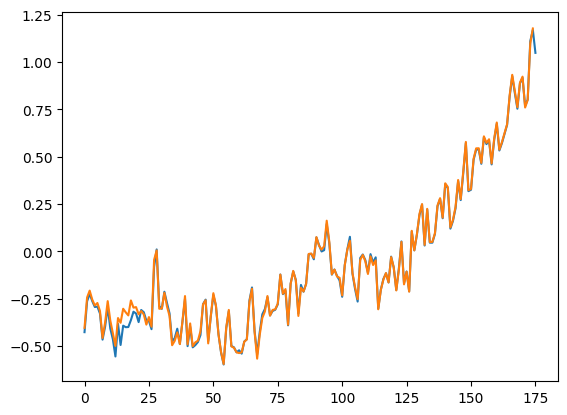

In [10]:
plt.plot(obs_all_updated.sel(region = 'GSAT'))
plt.plot(obs_all.sel(region = 'GSAT'))

plt.show()

In [11]:
ref_period = (1850, 1900)
current_year = 2025
target_reg = ['GSAT']
constrain_used_reg = ['GSAT']


from f1_0_H_sum_multi_region_constrain import *

constrain_func = constrain_sum_reg
obs = obs_all_updated
obs_200runs = obs_200runs_updated
ln_mod = ln_mod_all_updated
mod_his = mod_all_his_fu
mod_da = mod_all_his_fu
region_names = list(mod_da.names.values)
his_forcing = ['ALL']
sel_forcing=['ALL']

prior_mean, prior_cov, post_mean, post_cov = process_sum_multiple_region_mean_cov_constrain(constrain_func, constrain_used_reg, target_reg, his_forcing, sel_forcing, obs, obs_200runs, ln_mod, mod_his, mod_da)


prior_gsat_ref18 = change_ref(prior_mean.sel(forcing = 'ALL'), ref_period[0], ref_period[1])
post_gsat_ref18 = change_ref(post_mean.sel(forcing = 'ALL'), ref_period[0], ref_period[1])


post_warm_5_95 = rebaseline_with_uncertainty(
    post_gsat_ref18, post_cov
)[0]


prior_warm_5_95 = rebaseline_with_uncertainty(
    prior_gsat_ref18, prior_cov
)[0]



In [12]:
def find_yr(data, threshold):
    valid = data.where(data >= threshold, drop=True)
    if valid.size == 0:
        return np.nan
    return int(valid.year.values[0])

def summarize_threshold(post_mean, post_q, threshold):
    """
    post_mean : DataArray (median / best estimate)
    post_q    : DataArray (quantiles, dim='quantile')
    """

    yr_median = find_yr(post_mean, threshold)
    yr_low    = find_yr(post_q.sel(quantile='5th'), threshold)
    yr_high   = find_yr(post_q.sel(quantile='95th'), threshold)

    result = {
        "threshold": threshold,
        "median": yr_median,
        "low": yr_low,
        "high": yr_high
    }

    print(result)

    return result

post_time_15 = summarize_threshold(post_gsat_ref18, post_warm_5_95, 1.5)
post_time_2  = summarize_threshold(post_gsat_ref18, post_warm_5_95, 2)

prior_time_15 = summarize_threshold(prior_gsat_ref18, prior_warm_5_95, 1.5)
prior_time_2  = summarize_threshold(prior_gsat_ref18, prior_warm_5_95, 2)




{'threshold': 1.5, 'median': 2029, 'low': 2033, 'high': 2025}
{'threshold': 2, 'median': 2042, 'low': 2049, 'high': 2038}
{'threshold': 1.5, 'median': 2028, 'low': 2046, 'high': 2017}
{'threshold': 2, 'median': 2041, 'low': 2061, 'high': 2029}


In [13]:
gsat_15_post = post_time_15['median']
gsat_2_post = post_time_2['median']

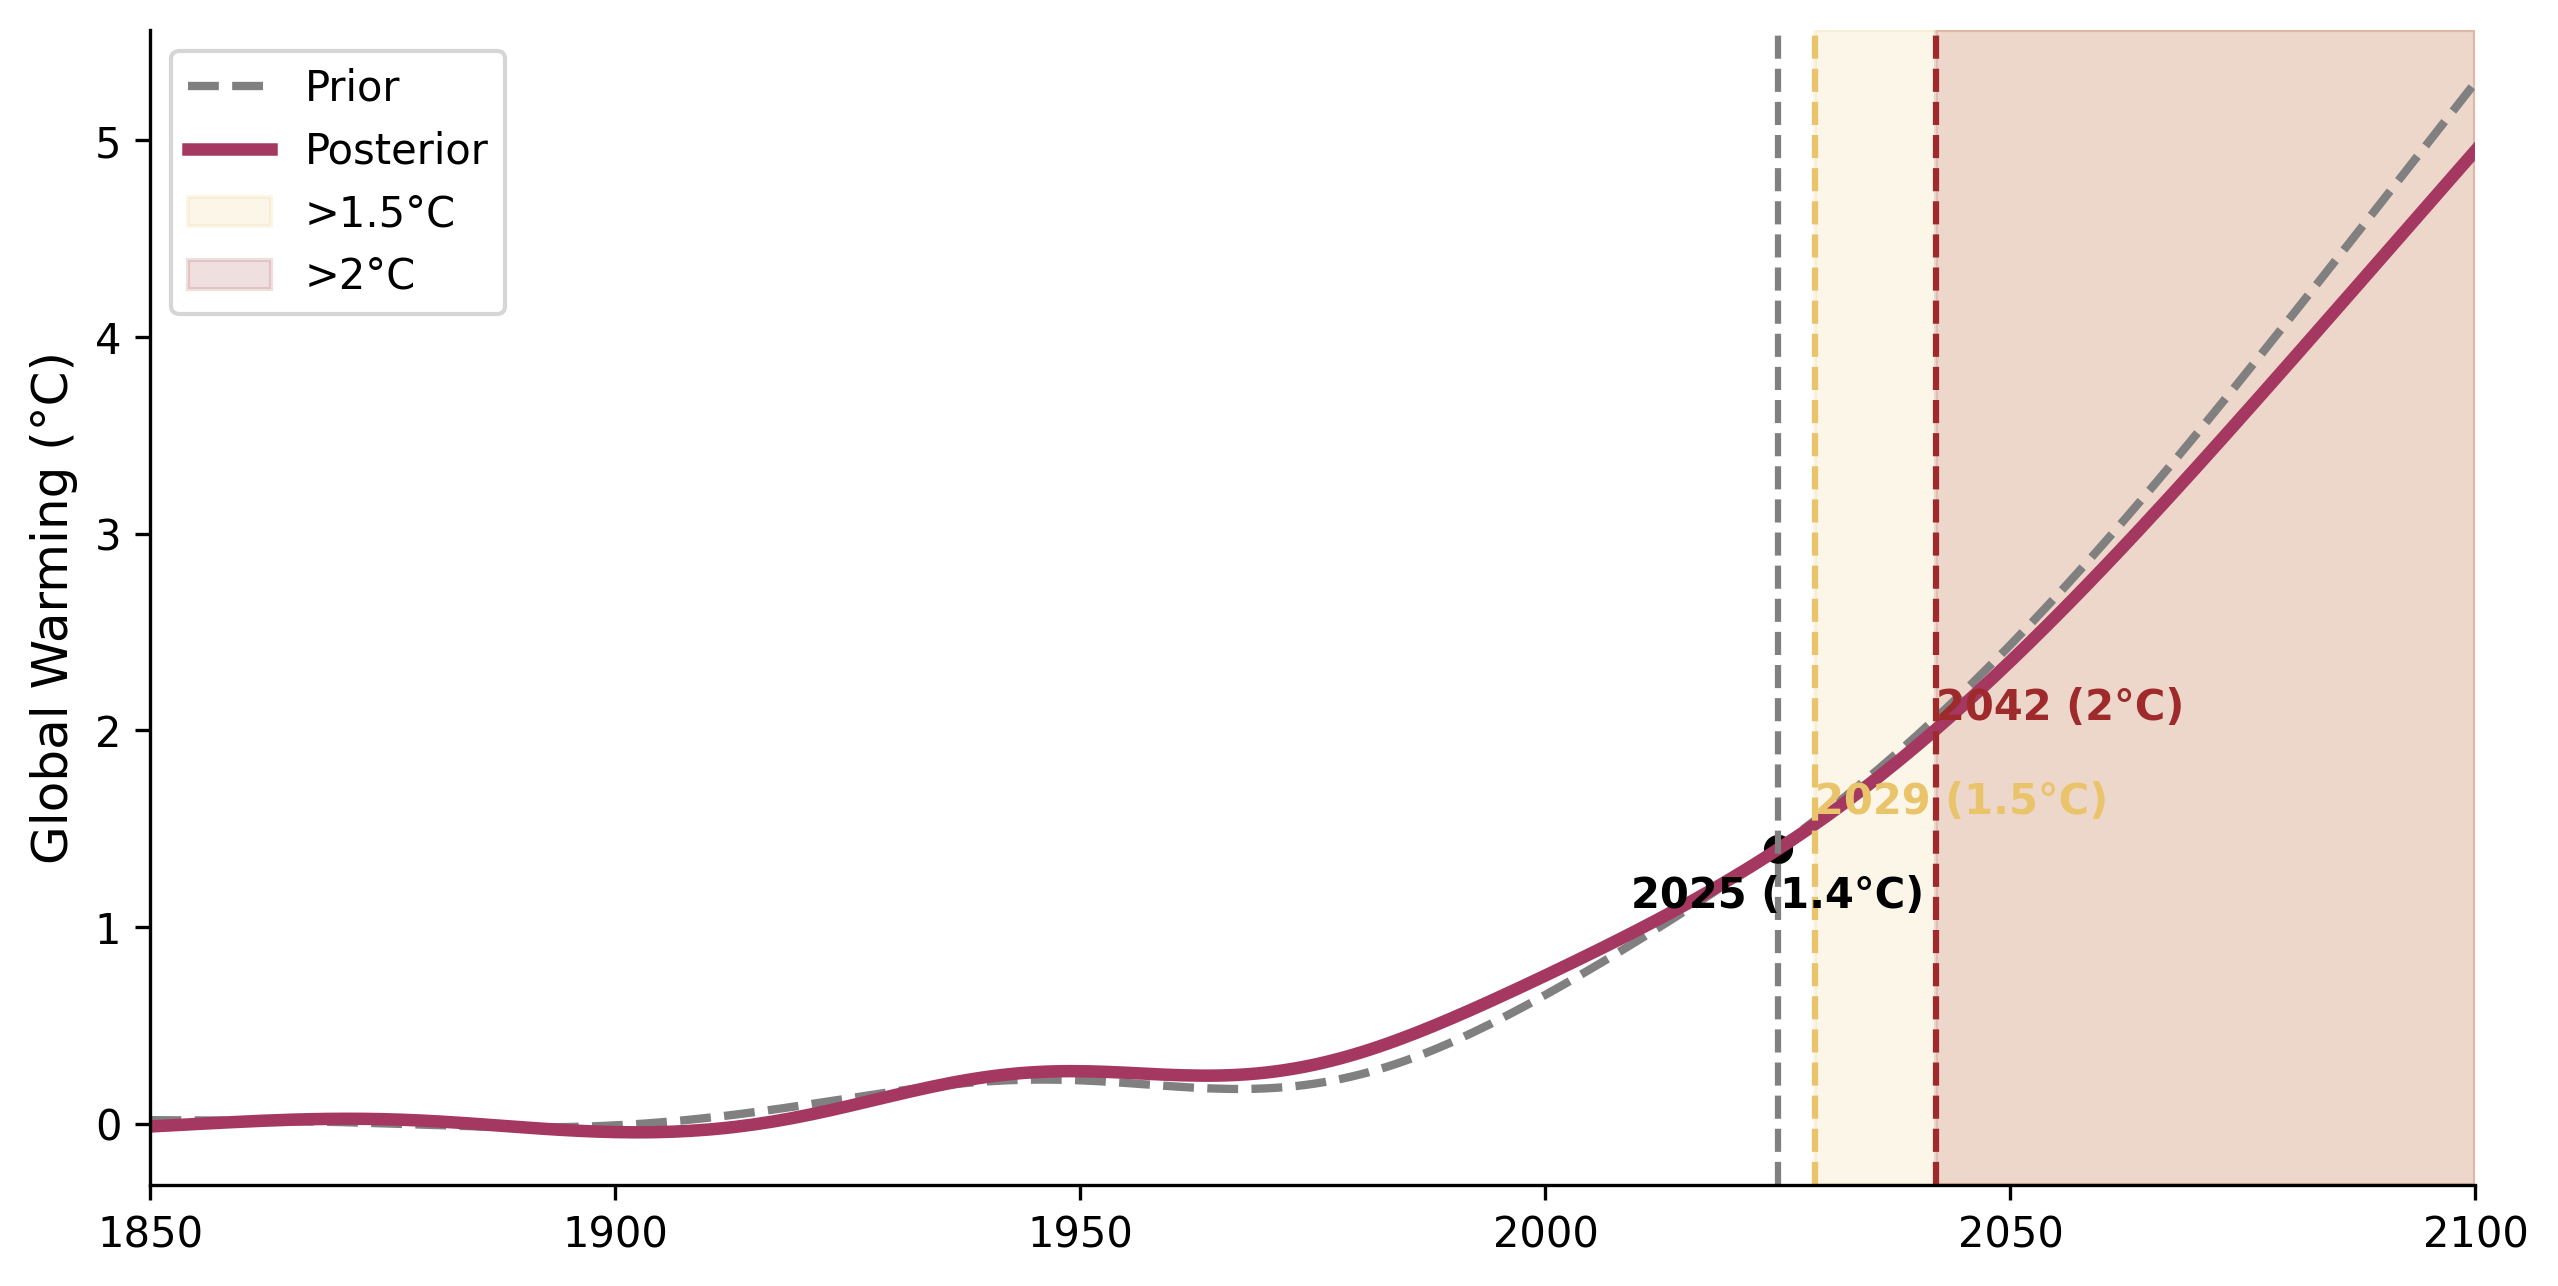

In [15]:

fig, ax = plt.subplots(1, 1, figsize=(10, 5
), dpi=300, sharey=True)

plt.plot(prior_gsat_ref18['year'], prior_gsat_ref18, label = 'Prior', color = 'gray', ls = '--', lw = 2)
plt.plot(post_gsat_ref18['year'], post_gsat_ref18, label = 'Posterior', color = '#a53860', ls = '-', lw = 3)



color_15 = '#e9c46a'
color_2 = '#9e2a2b'
# Shade time period after 1.5°C
ax.axvspan(gsat_15_post, 2100, color= color_15, alpha=0.15, label='>1.5°C')

# Shade time period after 2°C
ax.axvspan(gsat_2_post, 2100, color= color_2, alpha=0.15, label='>2°C')


ax.axvline(gsat_15_post, color= color_15, ls='--', lw=1.5)
ax.axvline(gsat_2_post, color= color_2, ls='--', lw=1.5)

ax.axvline(current_year, color='gray', ls='--', lw=1.5)

# ---- Label 1.5°C ----
y15 = post_gsat_ref18.sel(year=gsat_15_post)
ax.text(gsat_15_post, y15 + 0.05,
        f"{gsat_15_post} (1.5°C)",
        color= color_15, ha='left', weight = 'bold', fontsize=10)

# ---- Label 2°C ----
y2 = post_gsat_ref18.sel(year=gsat_2_post)
ax.text(gsat_2_post, y2 + 0.05,
        f"{gsat_2_post} (2°C)",
        color= color_2, ha='left', weight = 'bold', fontsize=10)

# ---- Label current year ----
y_curr = post_gsat_ref18.sel(year=current_year)
ax.scatter(current_year, y_curr, color='black')
ax.text(current_year, y_curr - 0.3,
        f"{current_year} (1.4°C)",
        color='black', ha='center', weight = 'bold', fontsize=10)

ax.set_ylabel("Global Warming (°C)", fontsize=12)

plt.xlim(1850, 2100)
plt.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
fig.savefig('./saved_figures/ED_Fig3.pdf', dpi=300, bbox_inches='tight')


### Load the regional, global land constraint results

### Constrained warming relative to current year 2025

In [16]:
path = './saved_data/'

def load_xr_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)
        
post_smooth_ALL_ref2025 = load_xr_pickle(path + '2.2_constrained_46reg_lsat_smoothed_warming_ref2025_1850-2100.pkl')
post_smooth_ALL_ref1850 = load_xr_pickle(path + '2.3_constrained_46reg_lsat_smoothed_warming_ref1850_1850-2100.pkl')


In [17]:
post_warming_15_ref2025 = post_smooth_ALL_ref2025.sel(year = slice(gsat_15_post-5, gsat_15_post+5)).mean('year').squeeze()
post_warming_2_ref2025 = post_smooth_ALL_ref2025.sel(year = slice(gsat_2_post-5, gsat_2_post+5)).mean('year').squeeze()

post_warming_15_ref2025

<xarray.DataArray 'post_mean_5_95_smooth' (region: 47, quantile: 3)> Size: 1kB
array([[ 0.20166266, -0.62177082,  0.93083091],
       [ 0.26300133, -0.36675869,  0.99282279],
       [ 0.26832218, -0.40929634,  0.89622799],
       [ 0.17230926, -0.17334368,  0.48747041],
       [ 0.18440906, -0.19319665,  0.53304903],
       [ 0.17913896, -0.12564383,  0.48924608],
       [ 0.15702691, -0.090154  ,  0.38447266],
       [ 0.12848061, -0.07280415,  0.29527434],
       [ 0.1153147 , -0.0328222 ,  0.30885826],
       [ 0.13199647, -0.15928984,  0.4078188 ],
       [ 0.16016114, -0.27407583,  0.62875001],
       [ 0.13710597, -0.14316434,  0.34251097],
       [ 0.1846761 , -0.24799826,  0.61847835],
       [ 0.12356794, -0.07601446,  0.30650405],
       [ 0.11632869, -0.10306539,  0.41351688],
       [ 0.07968941, -0.09820119,  0.24511112],
       [ 0.16258618, -0.37510094,  0.68245147],
       [ 0.2212241 , -0.16553318,  0.63334378],
       [ 0.24919802, -0.28856147,  0.73446602],
       [ 0.17416858, -0.09660169,  0.42491619],
...
       [ 0.13017278, -0.07432324,  0.29372825],
       [ 0.32776179, -0.48860669,  1.23724514],
       [ 0.26935235, -0.2434977 ,  0.8209187 ],
       [ 0.27232013, -0.24181452,  0.62907303],
       [ 0.21208349, -0.31310668,  0.72786411],
       [ 0.21327486, -0.08614952,  0.62983812],
       [ 0.2139288 , -0.15299783,  0.5931163 ],
       [ 0.20366028, -0.19957265,  0.6224414 ],
       [ 0.1914739 , -0.09781369,  0.43141742],
       [ 0.19432902, -0.14062799,  0.54371036],
       [ 0.1479812 , -0.1444171 ,  0.41127773],
       [ 0.10971039, -0.08496659,  0.26990539],
       [ 0.11704717, -0.08684124,  0.29413773],
       [ 0.16177297, -0.16576566,  0.49306816],
       [ 0.15558038, -0.05283195,  0.45510117],
       [ 0.07992294, -0.11961858,  0.30815381],
       [ 0.10964834, -0.12861734,  0.3036133 ],
       [ 0.13393722, -0.37098982,  0.67554155],
       [ 0.15677677, -0.53484556,  0.82312076],
       [ 0.16908808, -0.11592978,  0.39580548]])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    forcing      <U3 12B 'ALL'
  * quantile     (quantile) <U4 48B 'mean' '5th' '95th'
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) <U25 5kB 'Greenland/Iceland' ... 'Global Land'
    realization  int64 8B 100

In [18]:
current_yr = 2025
post_warming_current_year = post_smooth_ALL_ref1850.sel(year = current_yr, quantile = 'mean').squeeze()

percent_nowaday_15 = (post_warming_current_year / (post_warming_current_year + post_warming_15_ref2025)) * 100
percent_nowaday_2 = (post_warming_current_year / (post_warming_current_year + post_warming_2_ref2025)) * 100


## switch 5, 95th, cause it is on denorminator
percent_nowaday_15 = percent_nowaday_15.rename({'quantile': 'quantile'})
percent_nowaday_15 = percent_nowaday_15.assign_coords(
    quantile=['95th' if q == '5th' else '5th' if q == '95th' else q for q in percent_nowaday_15['quantile'].values]
)

percent_nowaday_2 = percent_nowaday_2.rename({'quantile': 'quantile'})
percent_nowaday_2 = percent_nowaday_2.assign_coords(
    quantile=['95th' if q == '5th' else '5th' if q == '95th' else q for q in percent_nowaday_2['quantile'].values]
)
percent_nowaday_15

<xarray.DataArray 'post_mean_5_95_smooth' (region: 47, quantile: 3)> Size: 1kB
array([[ 92.73418509, 131.85193508,  73.44025277],
       [ 91.85010606, 114.12080956,  74.90890862],
       [ 92.5546153 , 113.98704015,  78.82148123],
       [ 91.73895032, 109.96141884,  79.69689318],
       [ 91.81585755, 110.30029076,  79.51299384],
       [ 91.37410102, 107.09061296,  79.50255847],
       [ 91.33360804, 105.76164952,  81.1473137 ],
       [ 91.28766438, 105.71724575,  82.01182552],
       [ 91.41319067, 102.74710711,  79.8982171 ],
       [ 91.67667966, 112.30439428,  78.09410892],
       [ 91.03327884, 120.27284239,  72.11456994],
       [ 92.69749608, 108.96317857,  83.55624994],
       [ 91.03628491, 115.23715876,  75.20199748],
       [ 89.94060925, 107.38864168,  78.28245608],
       [ 92.48480597, 107.75791508,  77.58839376],
       [ 92.49260226, 111.11391242,  80.0219189 ],
       [ 92.82176545, 121.71601173,  75.49417136],
       [ 91.33436083, 107.64188167,  78.63939156],
       [ 91.26498665, 112.46429758,  77.99769183],
       [ 91.29626932, 105.58291445,  81.13015979],
...
       [ 90.60057058, 106.29641903,  81.03089931],
       [ 92.43766058, 113.88969585,  76.4047323 ],
       [ 90.64331877, 110.29211397,  76.06848534],
       [ 91.28699316, 109.26027917,  81.93459251],
       [ 91.35459471, 116.24043563,  75.48384202],
       [ 91.51338399, 103.89174323,  78.5011499 ],
       [ 91.10277156, 107.50903532,  78.69270808],
       [ 91.95094122, 109.38280422,  78.89326805],
       [ 90.46952084, 105.68756551,  80.81747343],
       [ 91.5542675 , 107.15315787,  79.48491227],
       [ 91.4764403 , 110.00295168,  79.43035032],
       [ 91.86469449, 107.36346471,  82.1108539 ],
       [ 91.67092503, 107.22836244,  81.41162547],
       [ 91.14209652, 111.0600876 ,  77.14745637],
       [ 91.2849588 , 103.35061975,  78.16961838],
       [ 93.767174  , 111.04767309,  79.59950816],
       [ 91.54942034, 112.1422021 ,  79.64361642],
       [ 92.10044492, 131.16052523,  69.80290369],
       [ 91.40641432, 147.21763972,  66.9521042 ],
       [ 91.79812269, 106.52552028,  82.70304105]])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) <U25 5kB 'Greenland/Iceland' ... 'Global Land'
    realization  int64 8B 100
  * quantile     (quantile) <U4 48B 'mean' '95th' '5th'

In [45]:
percent_nowaday_2.sel(quantile = 'mean').max()

<xarray.DataArray 'post_mean_5_95_smooth' ()> Size: 8B
array(76.14031338)
Coordinates:
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    realization  int64 8B 100
    quantile     <U4 16B 'mean'

### Map plotting

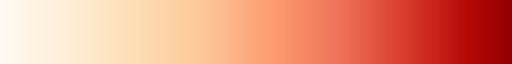

In [19]:
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap


# cmap_percent = modify_cmap('twilight', start=0.0, end=0.9, gamma=1.0, white_strength=0.7)   # example: different color map
# bounds2 = np.arange(50, 110, 10)  # example levels
# norm2 = mcolors.BoundaryNorm(boundaries=bounds2, ncolors=256, extend='neither')

# n_colors = len(bounds2) - 1  # = 5

# # Get discrete colors from the colormap
# colors_n = [cmap_percent(i / (n_colors - 1)) for i in range(n_colors)]

# # Swap the 5th color into 3rd position
# # Note: Python is 0-based -> 5th = index 4, 3rd = index 2
# colors_n[2], colors_n[4] = colors_n[4], colors_n[2]

# # Create a new colormap with the modified order
# cmap_percent = mcolors.ListedColormap(colors_n)

# # Recreate the norm
# norm2 = mcolors.BoundaryNorm(boundaries=bounds2, ncolors=cmap_percent.N, extend='neither')

 
cmap_percent = modify_cmap('OrRd', start=0.0, end=0.95, gamma=1.0, white_strength=0.3)
bounds2 = np.arange(50, 110, 10)  # 50, 60, 70, 80, 90, 100, 110
norm2 = mcolors.BoundaryNorm(boundaries=bounds2, ncolors=256, extend='neither')

cmap_percent

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_56892/132762987.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


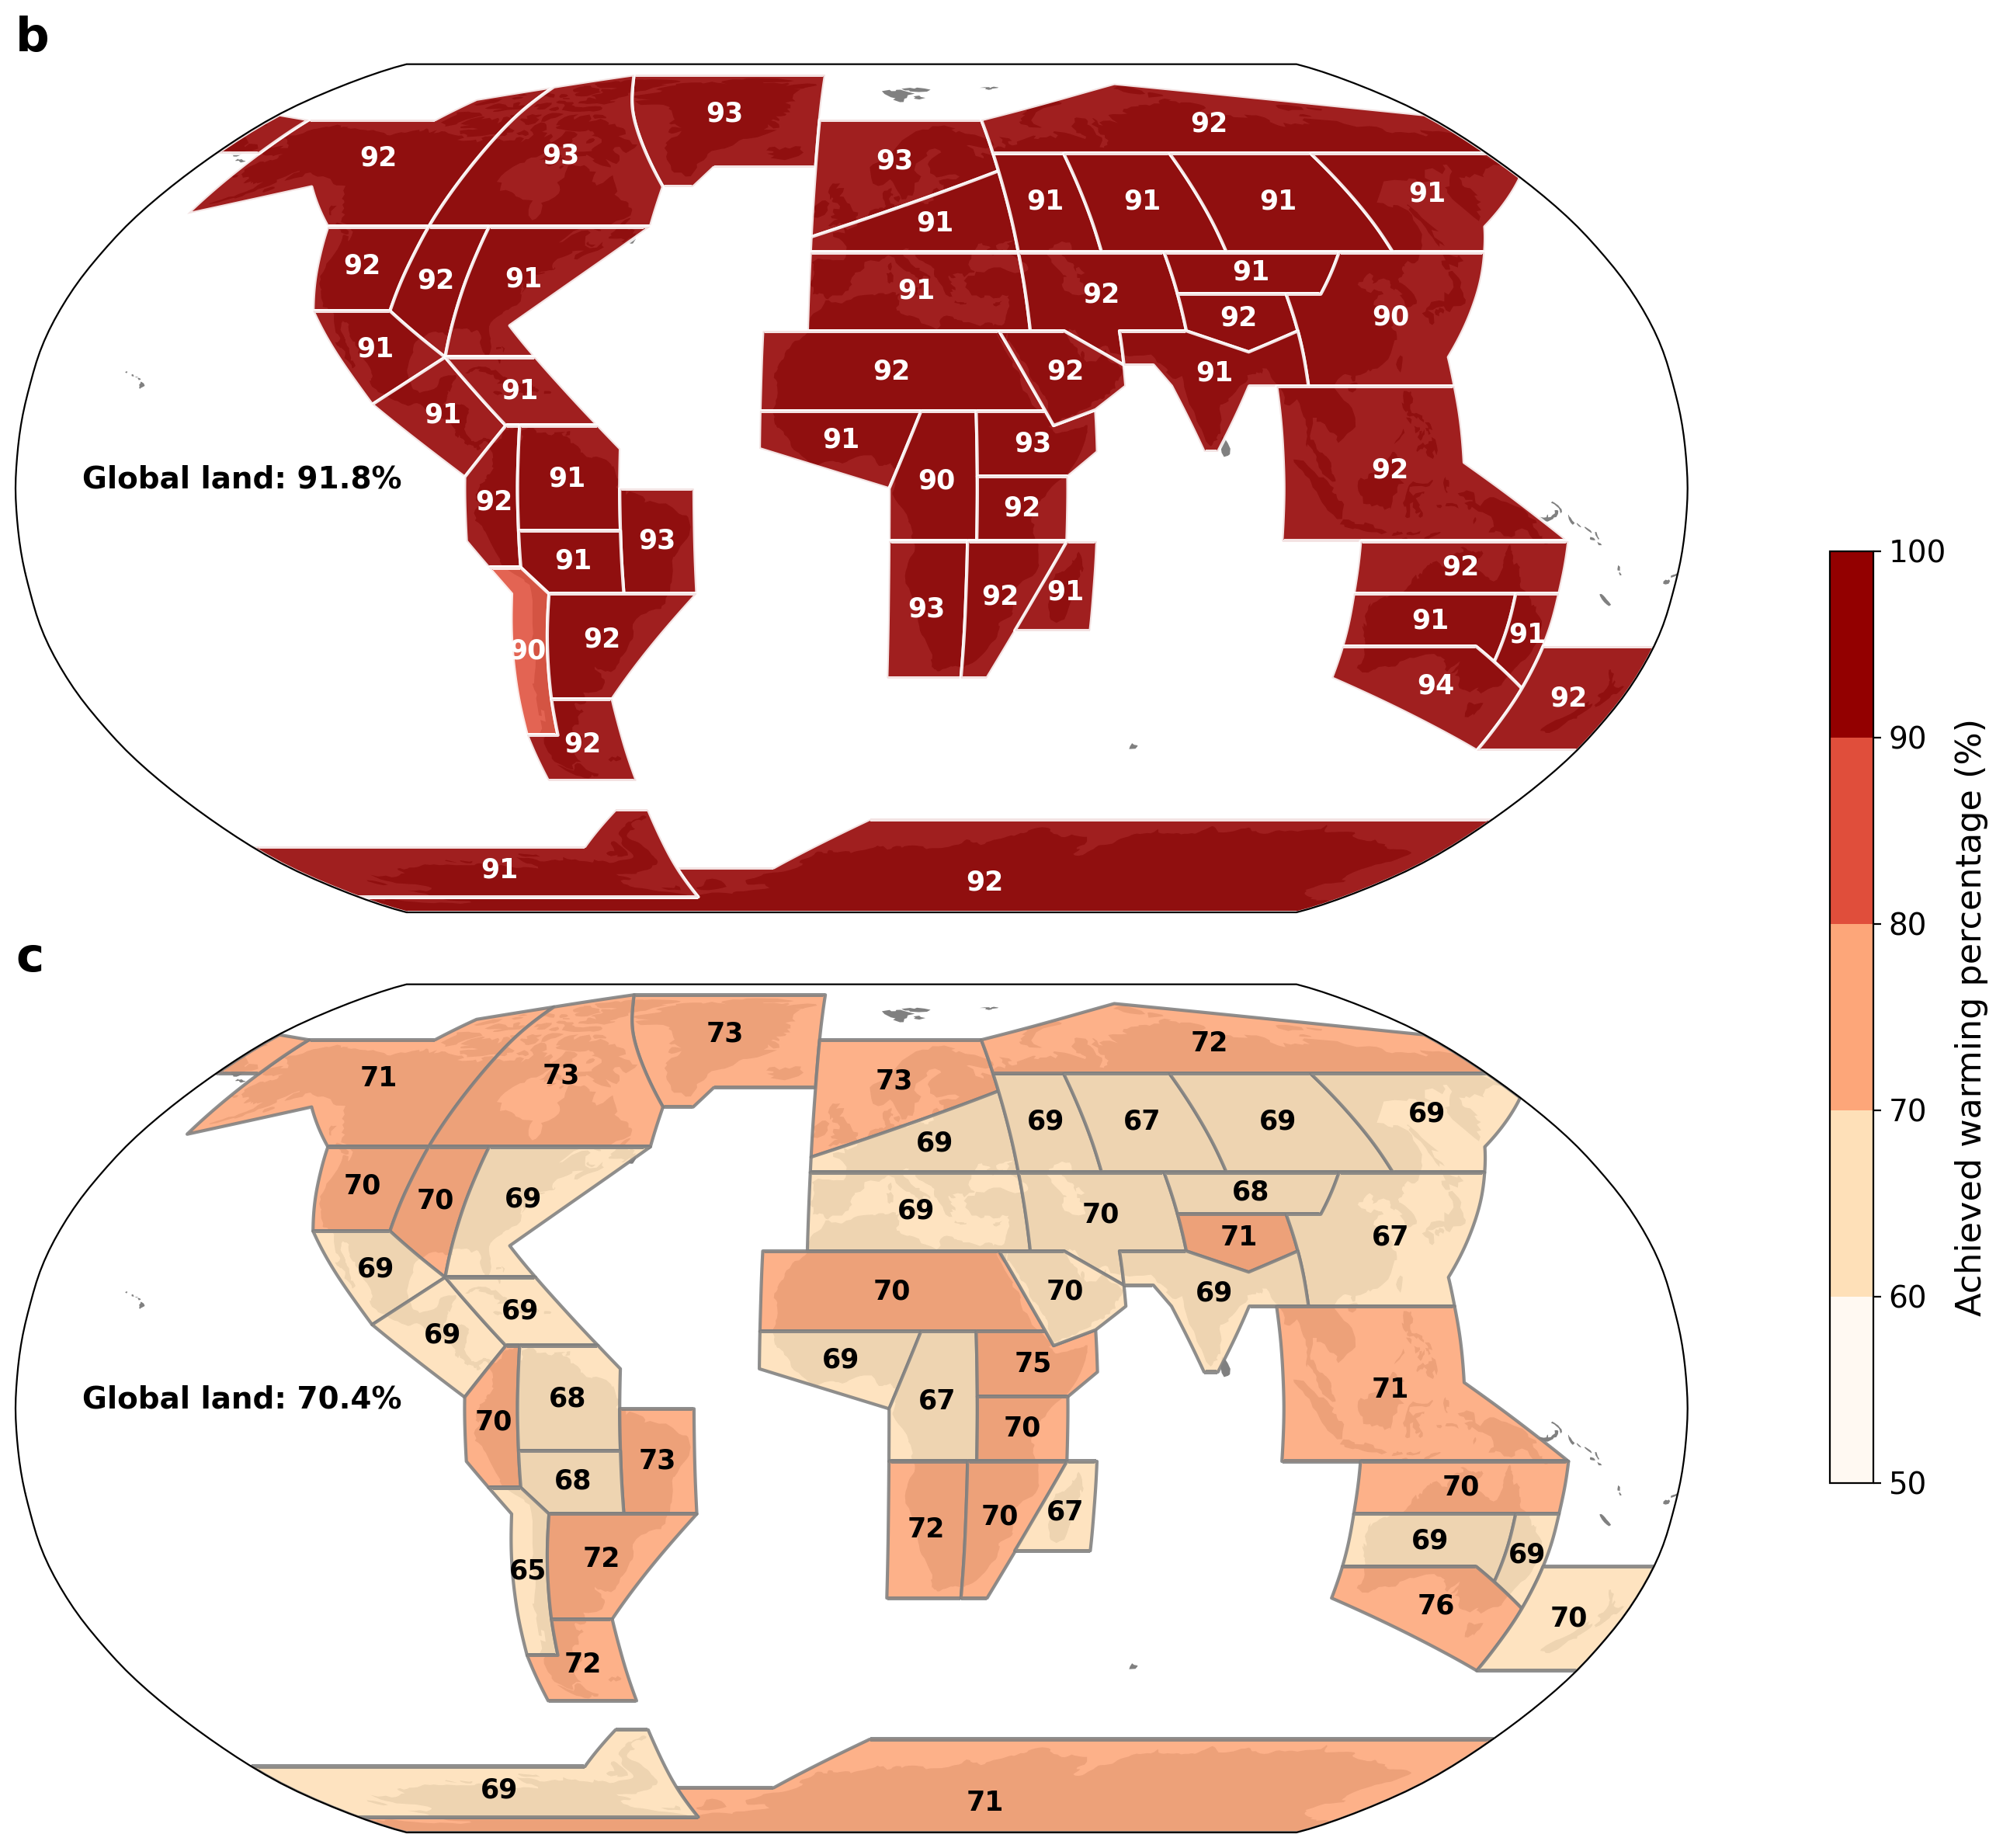

In [20]:
def plot_panel(ax, data, title, cmap, norm, decimals,
               global_value=None, unit="°C"):
    
    ax.set_global()
    norm0 = plot_ar6_region_data_on_ax_new(
        ax, data, cmap=cmap, norm=norm, decimals=decimals
    )

    # ---- Add title ----
    ax.set_title(title, fontsize=22, fontweight='bold', loc='left')

    # ---- Add the global value with a unit ----
    if global_value is not None:
        ax.text(
            0.04, 0.5,
            f"Global land: {global_value:.1f}{unit}",   # unit inserted here
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=4)
        )

    return norm0

# ---- Data dictionary ----
# data_dict = {
#     "(b) Nowadays to 1.5°C": percent_nowaday_15.sel(quantile = 'mean'),     # existing data
#     "(c) Nowadays to 2°C": percent_nowaday_2.sel(quantile = 'mean')    # add your second data array here
# }

data_dict = {
    "b": percent_nowaday_15.isel(region = slice(0,46)).sel(quantile = 'mean'),     # existing data
    "c": percent_nowaday_2.isel(region = slice(0,46)).sel(quantile = 'mean')    # add your second data array here
}

global_15 = percent_nowaday_15.where(percent_nowaday_15.abbrevs == 'LSAT', drop=True).sel(quantile = 'mean').values.item()
global_2 = percent_nowaday_2.where(percent_nowaday_2.abbrevs == 'LSAT', drop=True).sel(quantile = 'mean').values.item()

global_values = {
    "b": global_15,
    "c": global_2
}

# ---- Plot 2 panels ----
fig, axes = plt.subplots(2, 1, figsize=(14, 12), subplot_kw={'projection': ccrs.Robinson()}, dpi=200)

for ax, (label, data) in zip(axes, data_dict.items()):
    plot_panel(ax, data, f"{label}", cmap_percent, norm2, decimals = 0, global_value=global_values[label], unit = '%')

# ---- Shared colorbar ----
sm = mpl.cm.ScalarMappable(cmap=cmap_percent, norm=norm2)
sm.set_array([])

# [left, bottom, width, height] in figure coordinates (0–1)
cbar_ax = fig.add_axes([0.95, 0.2, 0.02, 0.5])  
cb = fig.colorbar(sm, cax=cbar_ax)
cb.ax.tick_params(labelsize=14)
cb.set_label("Achieved warming percentage (%)", fontsize=16)

plt.tight_layout()
plt.show()
fig.savefig('./saved_figures/Fig_1b-c.pdf', dpi=300, bbox_inches='tight')


In [21]:
from PIL import Image
from pdf2image import convert_from_path
import os

# Paths to your PDFs
pdf_1a = './saved_figures/Fig_1a.pdf'  # Update path if needed
pdf_1bc = './saved_figures/Fig_1b-c.pdf'  # Update path if needed
output_pdf = './saved_figures/Fig_1_combined.pdf'

# pdf2image requires Poppler's command-line tools. Jupyter kernels may not
# inherit Homebrew's bin directory, so locate it explicitly on macOS.
poppler_path = next((path for path in ('/opt/homebrew/bin', '/usr/local/bin')
                     if os.path.isfile(os.path.join(path, 'pdfinfo'))), None)
if poppler_path is None:
    raise RuntimeError('Poppler was not found. Install it with: brew install poppler')

# Convert PDFs to images
print("Converting PDFs to images...")
images_1a = convert_from_path(pdf_1a, dpi=300, poppler_path=poppler_path)
images_1bc = convert_from_path(pdf_1bc, dpi=300, poppler_path=poppler_path)

# Get the first page of each (assuming single-page PDFs)
img_1a = images_1a[0]
img_1bc = images_1bc[0]

# Get dimensions
w_1a, h_1a = img_1a.size
w_1bc, h_1bc = img_1bc.size

# Resize to same height for side-by-side layout
# Keep aspect ratio, resize to max height
max_height = max(h_1a, h_1bc)
scale_1a = max_height / h_1a
scale_1bc = max_height / h_1bc

img_1a = img_1a.resize((int(w_1a * scale_1a), max_height), Image.Resampling.LANCZOS)
img_1bc = img_1bc.resize((int(w_1bc * scale_1bc), max_height), Image.Resampling.LANCZOS)

# Create new image with both side-by-side (with small margin)
margin = 20
total_width = img_1a.width + img_1bc.width + margin
total_height = max_height

combined = Image.new('RGB', (total_width, total_height), color='white')

# Paste images
combined.paste(img_1a, (0, 0))
combined.paste(img_1bc, (img_1a.width + margin, 0))

# Save as PDF
combined.convert('RGB').save(output_pdf, 'PDF', quality=95)
print(f"Combined figure saved to: {output_pdf}")


Converting PDFs to images...
Combined figure saved to: ./saved_figures/Fig_1_combined.pdf


In [22]:
post_warming_current_year

<xarray.DataArray 'post_mean_5_95_smooth' (region: 47)> Size: 376B
array([2.57383688, 2.96405089, 3.33555046, 1.91349421, 2.06883932,
       1.89761805, 1.65487949, 1.3462171 , 1.22761371, 1.4538667 ,
       1.62601173, 1.74041398, 1.87558684, 1.104816  , 1.43158461,
       0.98178909, 2.10240221, 2.33166437, 2.60366566, 1.82691099,
       2.10940995, 1.63737276, 1.2215394 , 1.90144413, 1.49597977,
       1.83420205, 1.63723306, 1.25472812, 4.00637047, 2.6093644 ,
       2.85312369, 2.24105178, 2.2997982 , 2.19051433, 2.32657695,
       1.8175951 , 2.1065847 , 1.58816193, 1.23886081, 1.28823694,
       1.66453918, 1.62961349, 1.20236765, 1.18787609, 1.5615661 ,
       1.66756961, 1.89248969])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    quantile     <U4 16B 'mean'
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) <U25 5kB 'Greenland/Iceland' ... 'Global Land'
    realization  int64 8B 100

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_56892/235690464.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


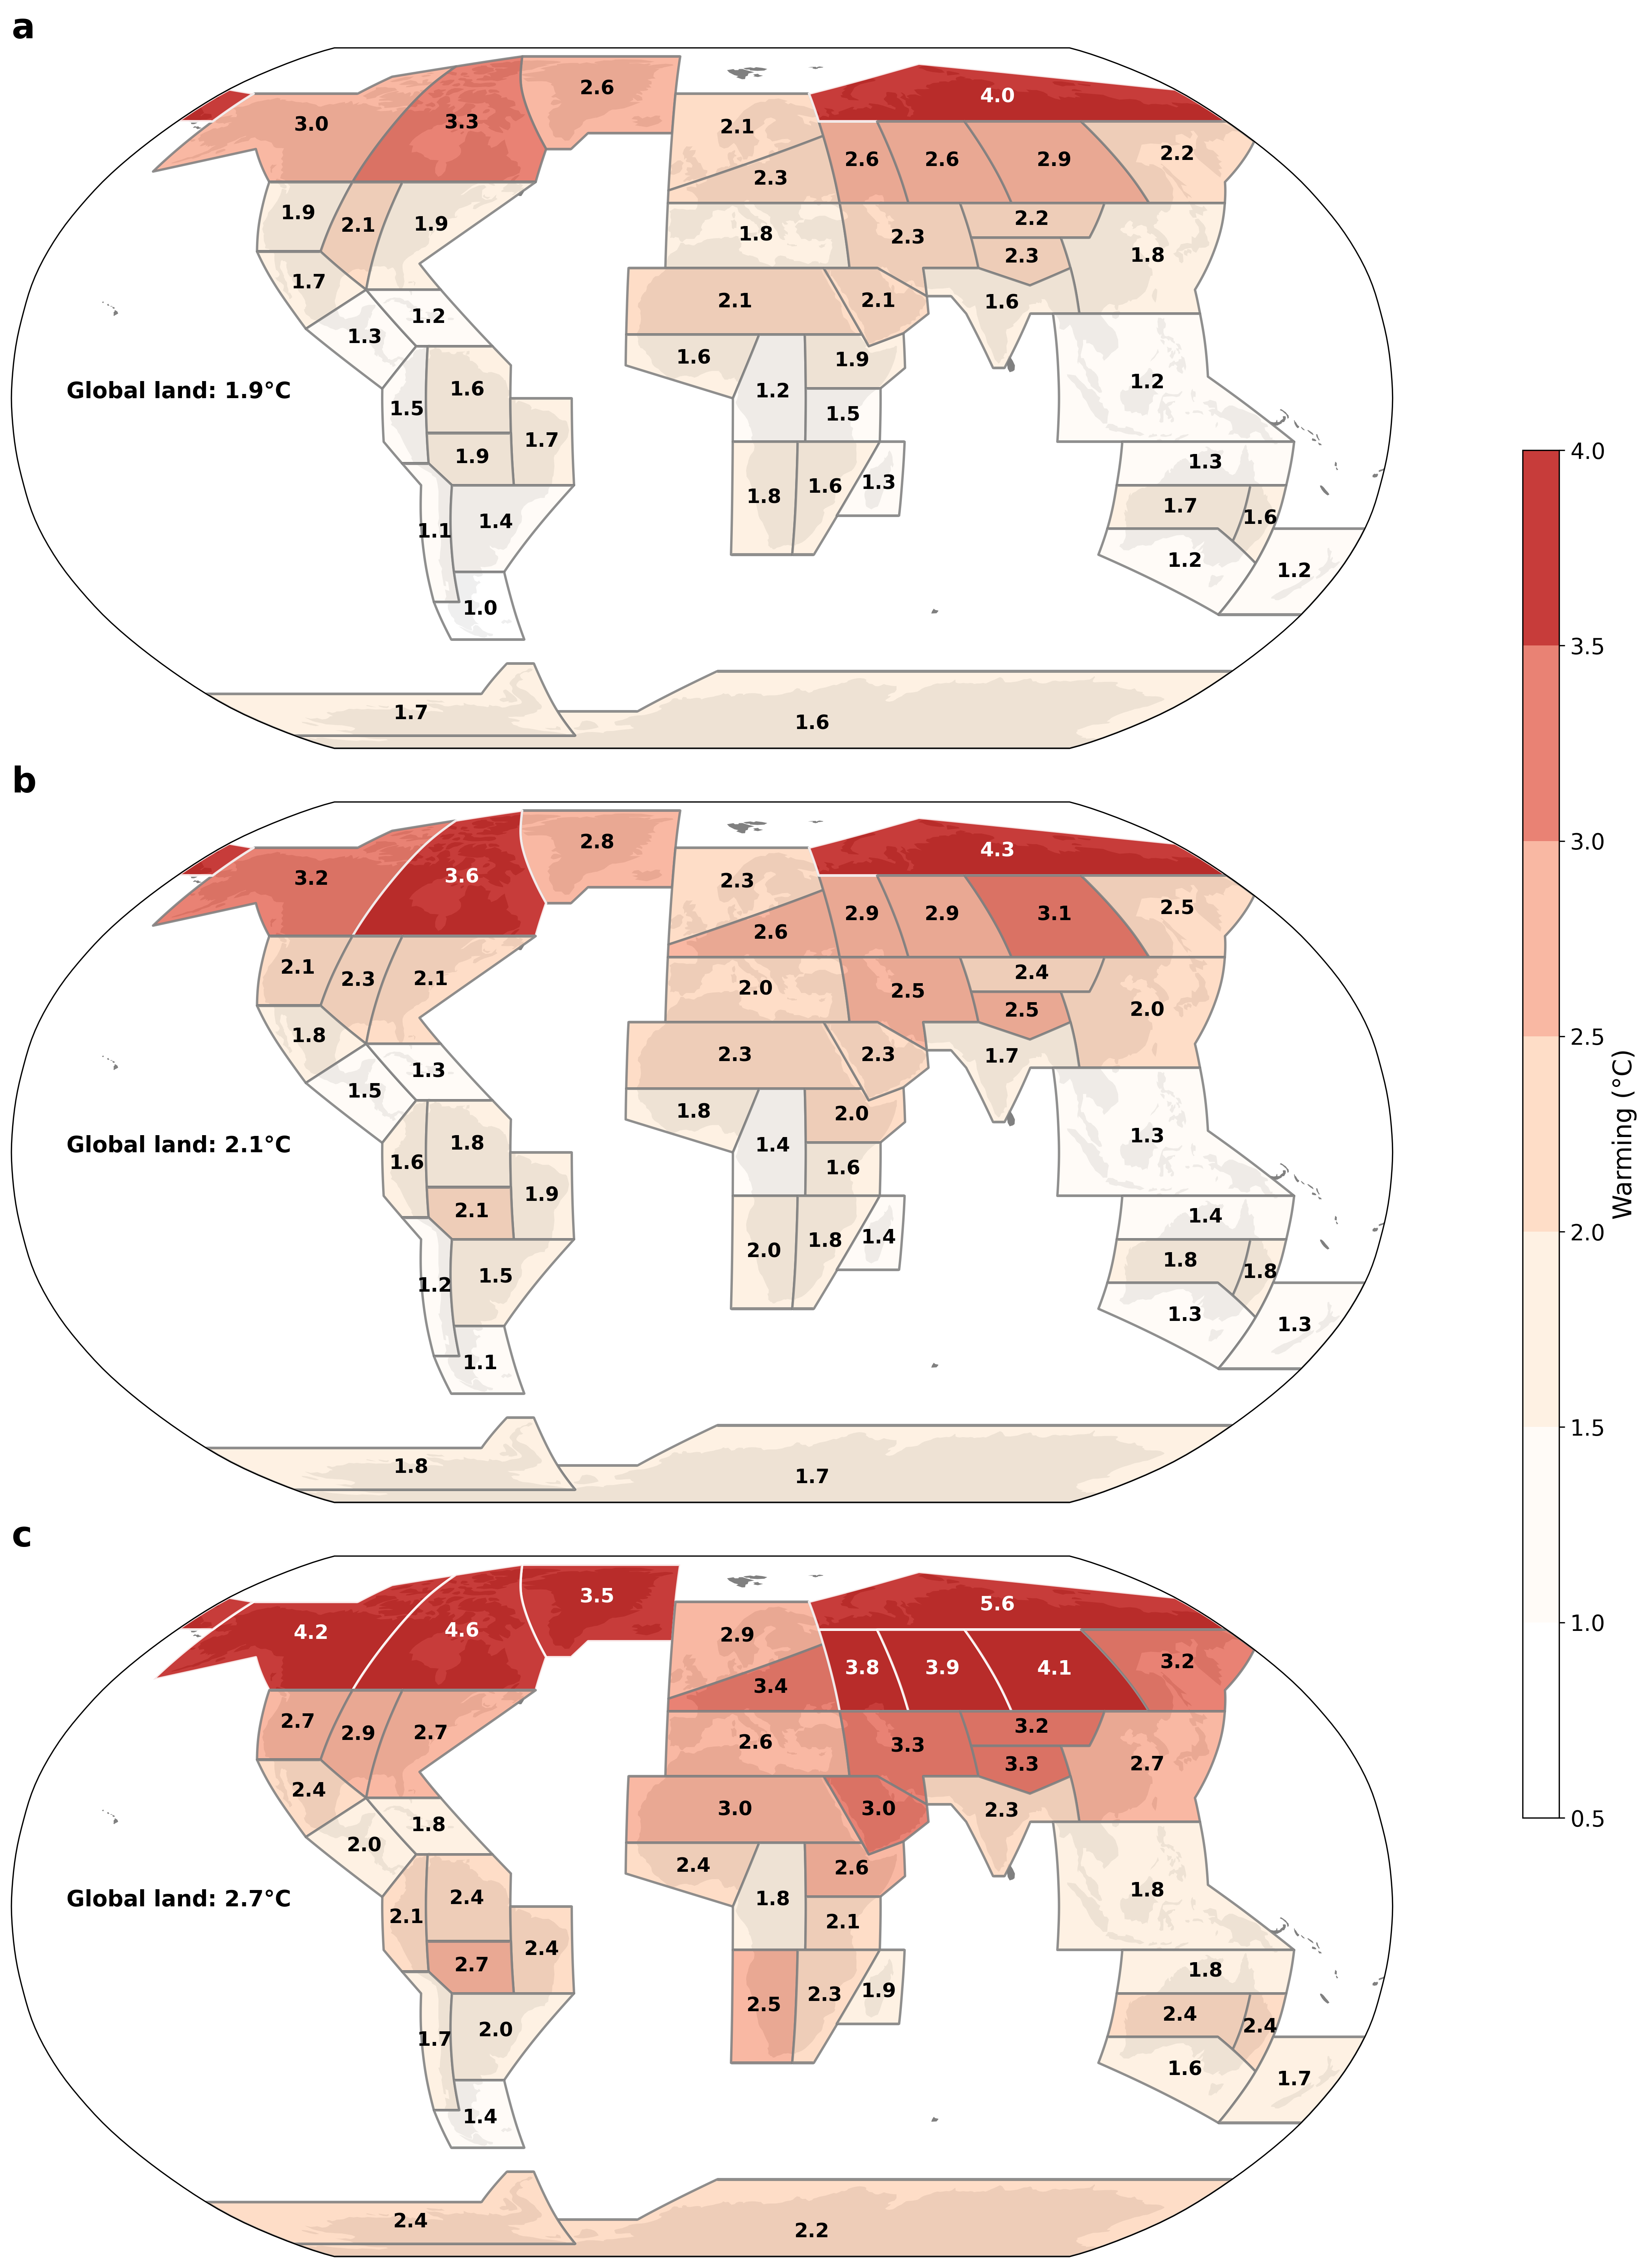

In [23]:
def set_cmap_alpha(cmap, alpha=1.0):
    colors = cmap(np.arange(cmap.N))
    colors[:, -1] = alpha
    return mpl.colors.ListedColormap(colors)

cmap = modify_cmap('OrRd', start=0.0, end=0.95, gamma=1.0, white_strength=1.0)
colors_array = cmap(np.linspace(0, 1, 256))
truncated_colors = colors_array[:230]
truncated_cmap = mcolors.LinearSegmentedColormap.from_list('truncated_YlOrBr', truncated_colors)
cmap_with_alpha = set_cmap_alpha(truncated_cmap, alpha=0.88)


# ---- Data dictionary ----
# data_dict = {
#     "1.5°C Warming world": post_warming_15_ref2025.sel(quantile = 'mean') + post_warming_current_year,
#     "2°C Warming world": post_warming_2_ref2025.sel(quantile = 'mean') + post_warming_current_year    # add your second data array here
# }

data_current = post_warming_current_year.isel(region = slice(0, 46))
data_15 = (post_warming_15_ref2025.sel(quantile = 'mean') + post_warming_current_year).isel(region = slice(0, 46))
data_2 = (post_warming_2_ref2025.sel(quantile = 'mean') + post_warming_current_year).isel(region = slice(0, 46))

data_dict = {
    "a": data_current,
    "b": data_15,
    "c": data_2
}

global_current = post_warming_current_year.where(post_warming_current_year.abbrevs == 'LSAT', drop=True).values.item()

global_15 = (post_warming_15_ref2025.sel(quantile = 'mean') + post_warming_current_year).where(post_warming_15_ref2025.abbrevs == 'LSAT', drop=True).values.item()

global_2 = (post_warming_2_ref2025.sel(quantile = 'mean') + post_warming_current_year).where(post_warming_2_ref2025.abbrevs == 'LSAT', drop=True).values.item()

global_values = {
    "a": global_current,
    "b": global_15,
    "c": global_2
}

bounds = np.arange(0.5, 4.5, 0.5)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='neither')

# ---- Plot 3 panels: current year, 1.5°C world, and 2°C world ----
fig, axes = plt.subplots(3, 1, figsize=(16, 20), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
for ax, (label, data) in zip(axes, data_dict.items()):
    plot_panel(ax, data, f"{label}", cmap_with_alpha, norm, decimals = 1, global_value=global_values[label], unit = '°C')

# ---- Shared colorbar ----
sm = mpl.cm.ScalarMappable(cmap=cmap_with_alpha, norm=norm)
sm.set_array([])


# [left, bottom, width, height] in figure coordinates (0–1)
cbar_ax = fig.add_axes([0.95, 0.2, 0.02, 0.6])  
cb = fig.colorbar(sm, cax=cbar_ax)
cb.ax.tick_params(labelsize=14)
cb.set_label("Warming (°C)", fontsize=16)

plt.tight_layout()
plt.show()
fig.savefig('./saved_figures/ED_Fig4.pdf', dpi=300, bbox_inches='tight')


In [24]:
40/56

0.7142857142857143

### Uncertainty

In [25]:
labels = post_warming_15_ref2025.coords['abbrevs'].values

groups = {
    'North and Central America': ['GIC', 'NWN', 'NEN', 'WNA', 'CNA', 'ENA', 'NCA', 'SCA', 'CAR'],
    'South America': ['NWS', 'NSA', 'NES', 'SAM', 'SWS', 'SES', 'SSA'],
    'Europe': ['NEU', 'WCE', 'EEU', 'MED'],
    'Africa': ['SAH', 'WAF', 'CAF', 'NEAF', 'SEAF', 'WSAF', 'ESAF', 'MDG'],
    'Asia': ['RAR', 'WSB', 'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS'],
    'Australasia': ['SEA', 'NAU', 'CAU', 'EAU', 'SAU', 'NZ'],
    'Antarctica': ['EAN', 'WAN'],
    'Global land': ['LSAT']
}

# Create a mapping from abbrev to index
abbrev_to_index = {abbr: i for i, abbr in enumerate(labels)}
continent_indices = {k: [abbrev_to_index[abbr] for abbr in v] for k, v in groups.items()}


colors = {
    'North and Central America': '#c45a5c',  # soft green
    'South America': '#a9b5da',               # lavender blue
    'Europe': '#f5a966',                      # warm yellow-orange
    'Africa': '#bab1a0',                      # muted red
    'Asia': '#b47955',                        # light blue
    'Australasia': '#6e9c6d',                 # forest green
    'Antarctica': '#5590B4',                   # brick red
    'Global land': '#dda15e'
}

uncertainty_ref_period=(1850, 2025)
ref_period=(1850, 1900)
obs_adjust_ref_period=(1961, 2023)
warming_target_period=(2016, 2025)

In [26]:
post_warming_15_ref2025

<xarray.DataArray 'post_mean_5_95_smooth' (region: 47, quantile: 3)> Size: 1kB
array([[ 0.20166266, -0.62177082,  0.93083091],
       [ 0.26300133, -0.36675869,  0.99282279],
       [ 0.26832218, -0.40929634,  0.89622799],
       [ 0.17230926, -0.17334368,  0.48747041],
       [ 0.18440906, -0.19319665,  0.53304903],
       [ 0.17913896, -0.12564383,  0.48924608],
       [ 0.15702691, -0.090154  ,  0.38447266],
       [ 0.12848061, -0.07280415,  0.29527434],
       [ 0.1153147 , -0.0328222 ,  0.30885826],
       [ 0.13199647, -0.15928984,  0.4078188 ],
       [ 0.16016114, -0.27407583,  0.62875001],
       [ 0.13710597, -0.14316434,  0.34251097],
       [ 0.1846761 , -0.24799826,  0.61847835],
       [ 0.12356794, -0.07601446,  0.30650405],
       [ 0.11632869, -0.10306539,  0.41351688],
       [ 0.07968941, -0.09820119,  0.24511112],
       [ 0.16258618, -0.37510094,  0.68245147],
       [ 0.2212241 , -0.16553318,  0.63334378],
       [ 0.24919802, -0.28856147,  0.73446602],
       [ 0.17416858, -0.09660169,  0.42491619],
...
       [ 0.13017278, -0.07432324,  0.29372825],
       [ 0.32776179, -0.48860669,  1.23724514],
       [ 0.26935235, -0.2434977 ,  0.8209187 ],
       [ 0.27232013, -0.24181452,  0.62907303],
       [ 0.21208349, -0.31310668,  0.72786411],
       [ 0.21327486, -0.08614952,  0.62983812],
       [ 0.2139288 , -0.15299783,  0.5931163 ],
       [ 0.20366028, -0.19957265,  0.6224414 ],
       [ 0.1914739 , -0.09781369,  0.43141742],
       [ 0.19432902, -0.14062799,  0.54371036],
       [ 0.1479812 , -0.1444171 ,  0.41127773],
       [ 0.10971039, -0.08496659,  0.26990539],
       [ 0.11704717, -0.08684124,  0.29413773],
       [ 0.16177297, -0.16576566,  0.49306816],
       [ 0.15558038, -0.05283195,  0.45510117],
       [ 0.07992294, -0.11961858,  0.30815381],
       [ 0.10964834, -0.12861734,  0.3036133 ],
       [ 0.13393722, -0.37098982,  0.67554155],
       [ 0.15677677, -0.53484556,  0.82312076],
       [ 0.16908808, -0.11592978,  0.39580548]])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    forcing      <U3 12B 'ALL'
  * quantile     (quantile) <U4 48B 'mean' '5th' '95th'
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) <U25 5kB 'Greenland/Iceland' ... 'Global Land'
    realization  int64 8B 100

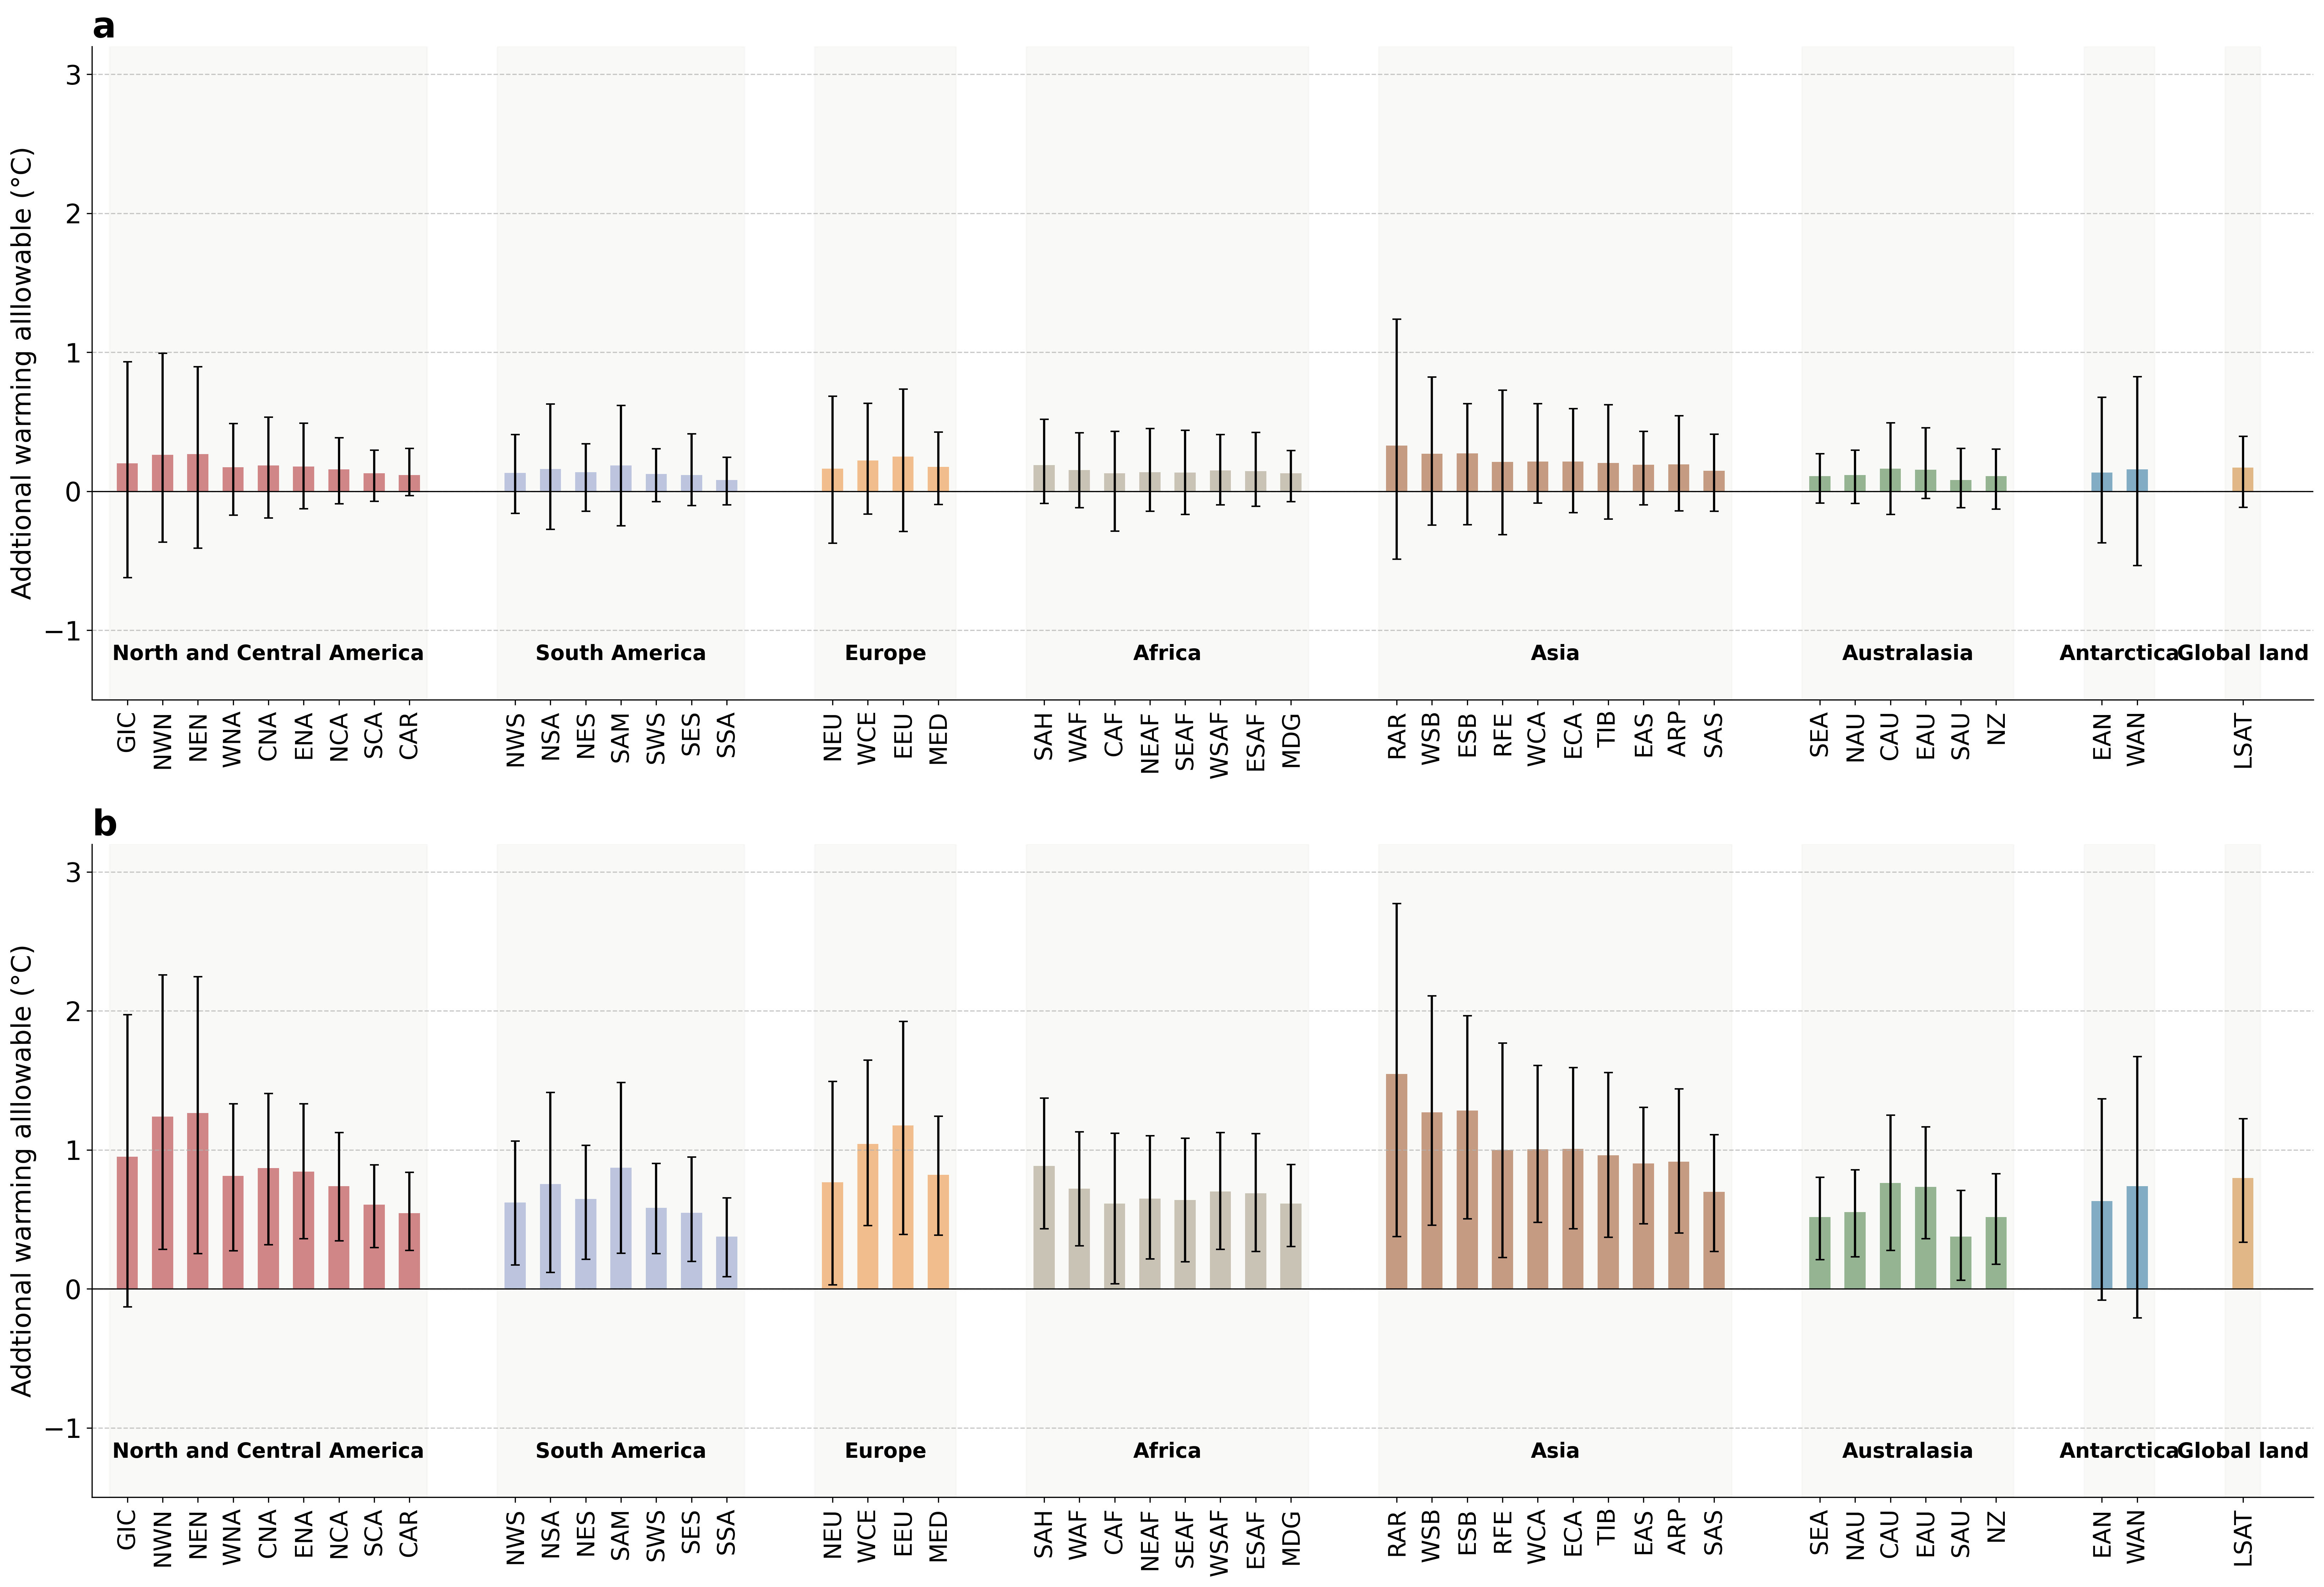

In [27]:
def plot_panel(ax, data, title, colors, continent_indices, labels, y_label, continent_height_value = -0.5, ylim_low = -1, ylim_high = 6, continent_label = 'True'):
    mean = data.sel(quantile='mean')
    err_lower = mean - data.sel(quantile='5th')
    err_upper = data.sel(quantile='95th') - mean

    bar_width = 0.6
    gap = 2

    x_ticks = []
    x_labels = []
    current_x = 0

    for continent, indices in continent_indices.items():
        for idx in indices:
            ax.bar(current_x, mean[idx], 
                   yerr=[[err_lower[idx]], [err_upper[idx]]],
                   color=colors[continent], capsize=3, alpha=1, width = bar_width)
            x_ticks.append(current_x)
            x_labels.append(labels[idx])
            current_x += 1
        current_x += gap

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90, fontsize=16)
    ax.set_ylabel(y_label, fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_title(title, loc='left', fontsize=24, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)


    # Background and continent labels
    current_x = 0
    for continent, indices in continent_indices.items():
        group_width = len(indices)
        ax.axvspan(current_x - 0.5, current_x + group_width - 0.5, color='#edede9', alpha=0.3)
        group_center = current_x + group_width / 2 - 0.5

        if continent_label == 'True':
            ax.text(group_center, continent_height_value,
                    continent, ha='center', va='top', fontsize=14, fontweight='bold')
        current_x += group_width + gap

    ax.set_ylim(ylim_low, ylim_high)
    ax.set_xlim(-1, current_x - gap + 1)  # enforce same scaling

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

# Create the figure with two rows instead of one
fig, axs = plt.subplots(2, 1, figsize=(22, 15), dpi=300, sharey=True)

# Top panel
plot_panel(
    axs[0],
    post_warming_15_ref2025,
    # '(a) Nowadays to 1.5°C, Allowable Remaining warming (°C)',
    'a',
    colors,
    continent_indices,
    labels,
    'Addtional warming alllowable (°C)',
    continent_height_value=-1.1,  # lift up labels for tighter spacing
    ylim_low=-1.5,
    ylim_high=3.2
)

# Bottom panel
plot_panel(
    axs[1],
    post_warming_2_ref2025,
    # '(b) Nowadays to 2°C, Allowable Remaining Addtional warming alllowable (°C)',
    'b',
    colors,
    continent_indices,
    labels,
    'Addtional warming alllowable (°C)',
    continent_height_value=-1.1,
    ylim_low=-1.5,
    ylim_high=3.2
)

plt.tight_layout(h_pad=2.0)  # reduce vertical spacing between subplots
# main_title = f"(a) Attributable warming to ALL-forcing"
# fig.suptitle(main_title, fontsize=20, fontweight='bold', x = 0.63, y=1.02, ha = 'right')

plt.show()
fig.savefig('./saved_figures/ED_Fig6.pdf', dpi=300, bbox_inches='tight')


In [28]:
35*5

175

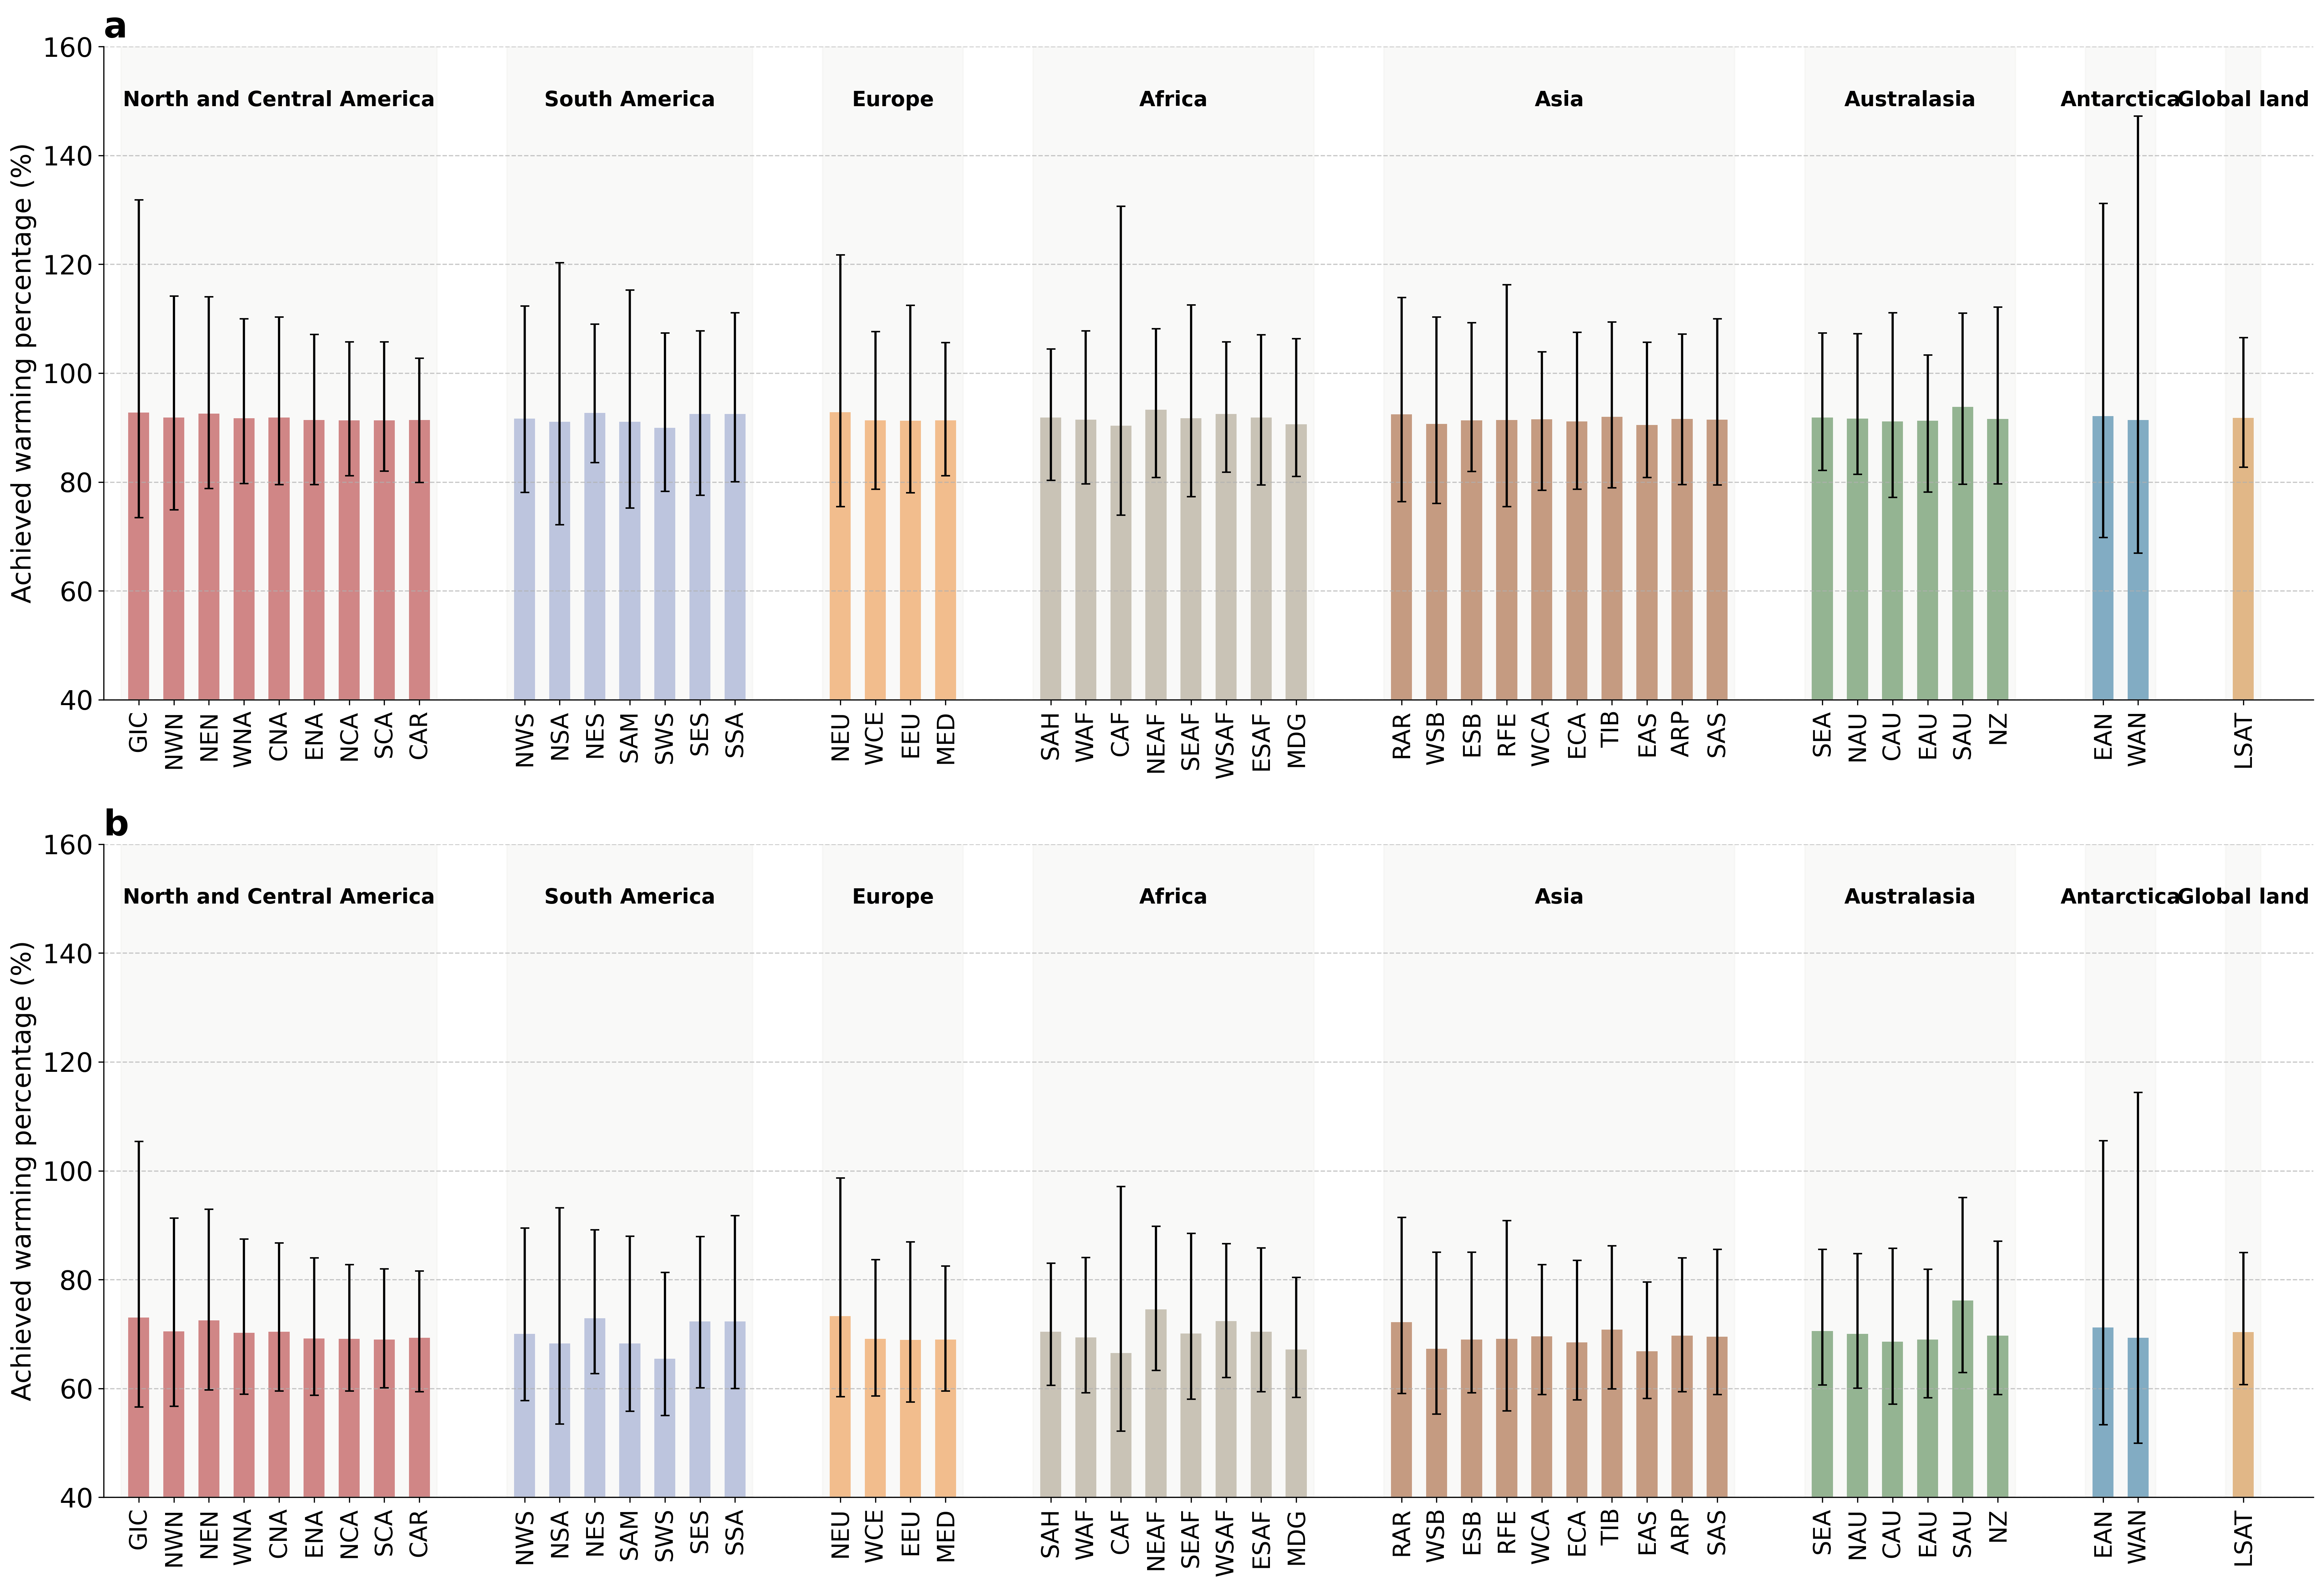

In [29]:

# Create the figure with two rows instead of one
fig, axs = plt.subplots(2, 1, figsize=(22, 15), dpi=300, sharey=True)

# Top panel
plot_panel(
    axs[0],
    percent_nowaday_15,
    # '(a) Nowadays to 1.5°C, Warming Occurred (%)',
    'a',
    colors,
    continent_indices,
    labels,
    'Achieved warming percentage (%)',
    continent_height_value=152,  # lift up labels for tighter spacing
    ylim_low=40,
    ylim_high=160
)

# Bottom panel
plot_panel(
    axs[1],
    percent_nowaday_2,
    # '(b) Nowadays to 2°C, Warming Occurred (%)',
    'b',
    colors,
    continent_indices,
    labels,
    'Achieved warming percentage (%)',
    continent_height_value=152,
    ylim_low=40,
    ylim_high=160
)

plt.tight_layout(h_pad=2.0)  # reduce vertical spacing between subplots
# main_title = f"(a) Attributable warming to ALL-forcing"
# fig.suptitle(main_title, fontsize=20, fontweight='bold', x = 0.63, y=1.02, ha = 'right')

plt.show()
fig.savefig('./saved_figures/ED_Fig5.pdf', dpi=300, bbox_inches='tight')


### AR6 region, area-mean-average

In [30]:
percent_reg_15 = percent_nowaday_15.sel(quantile = 'mean')
percent_reg_2 = percent_nowaday_2.sel(quantile = 'mean')
warming_reg_15 = (post_warming_15_ref2025.sel(quantile = 'mean') + post_warming_current_year)
warming_reg_2 = (post_warming_2_ref2025.sel(quantile = 'mean') + post_warming_current_year)


In [31]:
percent_reg_15_weighted_glob = compute_global_area_average(percent_reg_15)
percent_reg_2_weighted_glob = compute_global_area_average(percent_reg_2)

warming_reg_15_weighted_glob = compute_global_area_average(warming_reg_15)
warming_reg_2_weighted_glob = compute_global_area_average(warming_reg_2)

In [32]:
percent_15_constraint_glob = percent_nowaday_15.isel(region = slice(46, 47)).sel(quantile = 'mean')
percent_2_constraint_glob = percent_nowaday_2.isel(region = slice(46, 47)).sel(quantile = 'mean')

warming_15_constraint_glob = (post_warming_15_ref2025.sel(quantile = 'mean') + post_warming_current_year).isel(region = slice(46, 47))
warming_2_constraint_glob = (post_warming_2_ref2025.sel(quantile = 'mean') + post_warming_current_year).isel(region = slice(46, 47))


In [33]:
print(warming_15_constraint_glob)
print(warming_reg_15_weighted_glob)

print(warming_2_constraint_glob)
print(warming_reg_2_weighted_glob)


<xarray.DataArray 'post_mean_5_95_smooth' (region: 1)> Size: 8B
array([2.06157777])
Coordinates:
  * region       (region) int64 8B 46
    forcing      <U3 12B 'ALL'
    quantile     <U4 16B 'mean'
    abbrevs      (region) <U4 16B 'LSAT'
    names        (region) <U25 100B 'Global Land'
    realization  int64 8B 100
    year         int64 8B 2025
<xarray.DataArray ()> Size: 8B
array(2.09168023)
Coordinates:
    forcing      <U3 12B 'ALL'
    quantile     <U4 16B 'mean'
    realization  int64 8B 100
    year         int64 8B 2025
<xarray.DataArray 'post_mean_5_95_smooth' (region: 1)> Size: 8B
array([2.68961787])
Coordinates:
  * region       (region) int64 8B 46
    forcing      <U3 12B 'ALL'
    quantile     <U4 16B 'mean'
    abbrevs      (region) <U4 16B 'LSAT'
    names        (region) <U25 100B 'Global Land'
    realization  int64 8B 100
    year         int64 8B 2025
<xarray.DataArray ()> Size: 8B
array(2.73244457)
Coordinates:
    forcing      <U3 12B 'ALL'
    quantile     <U4 

In [34]:
print(percent_15_constraint_glob)
print(percent_reg_15_weighted_glob)

print(percent_2_constraint_glob)
print(percent_reg_2_weighted_glob)


<xarray.DataArray 'post_mean_5_95_smooth' (region: 1)> Size: 8B
array([91.79812269])
Coordinates:
  * region       (region) int64 8B 46
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    abbrevs      (region) <U4 16B 'LSAT'
    names        (region) <U25 100B 'Global Land'
    realization  int64 8B 100
    quantile     <U4 16B 'mean'
<xarray.DataArray ()> Size: 8B
array(91.71532635)
Coordinates:
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    realization  int64 8B 100
    quantile     <U4 16B 'mean'
<xarray.DataArray 'post_mean_5_95_smooth' (region: 1)> Size: 8B
array([70.36277196])
Coordinates:
  * region       (region) int64 8B 46
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    abbrevs      (region) <U4 16B 'LSAT'
    names        (region) <U25 100B 'Global Land'
    realization  int64 8B 100
    quantile     <U4 16B 'mean'
<xarray.DataArray ()> Size: 8B
array(70.1744242)
Coordinates:
    year         int64 8B 2025
    forcing      <

In [35]:
file_name = '2.0.real_obs_constrain_prior_post_warming_2016-2025_ref.1850-1900.nc'
post_warm = xr.open_dataarray(path + file_name).sel(scheme = 'post', quantile = 'mean')

global_constrained_warm = post_warm.sel(region = 46)
global_weighted_warm = compute_global_area_average(post_warm)


forcings = global_constrained_warm.forcing.values  # or da1.region.values
x = np.arange(len(forcings))
width = 0.35  # bar width




In [36]:
def plot_grouped_bars(ax, labels, data_dict, ylabel, ylim=None, xlim=None,
                      legend_loc="upper right", title=None, legend=True):

    # Two x positions: one for 1.5°C, one for 2°C
    x = np.array([0, 1])
    width = 0.30

    # Colors
    c15 = '#bc4749'
    c2  = '#4f772d'

    # Group keys by temperature target
    keys_15 = [k for k in data_dict if "1.5°C" in k]
    keys_2  = [k for k in data_dict if "2°C"  in k]
    print(keys_2)

    # Offsets for showing 2 bars in each group
    offsets = [-0.15, 0.15]   # adjust as needed

    # Plot 1.5°C bars at x=0
    for k, off in zip(keys_15, offsets):
        ax.bar(0 + off, data_dict[k], width,
               color=c15, alpha=0.7 if "Weighted" in k else 0.4,
               label=k)

    # Plot 2°C bars at x=1
    for k, off in zip(keys_2, offsets):
        ax.bar(1 + off, data_dict[k], width,
               color=c2, alpha=0.7 if "Weighted" in k else 0.4,
               label=k)

    # X-axis labels
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["1.5°C", "2°C"], fontsize=14)
    ax.tick_params(axis='y', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)



    ax.set_ylabel(ylabel, fontsize=14)
    if ylim: ax.set_ylim(ylim)
    if xlim: ax.set_xlim(xlim)
    if legend:
        ax.legend(loc=legend_loc)

    if title:
        ax.set_title(title, weight='bold', loc='left', fontsize=16, pad=6)


# ============================================================
# MASTER FUNCTION — (1 top) + (2 bottom)
# ============================================================
def plot_global_plus_two_panels(global_constrained, global_weighted, forcings,
                                percent_data, warming_data):

    # Create layout: 2 rows, 2 columns

    # GridSpec: row heights (top tall, bottom shorter)
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

    # ---------------------------------------------------------
    # PANEL A (top, spanning 2 columns)
    # ---------------------------------------------------------
    axA = fig.add_subplot(gs[0, :])

    x = np.arange(len(forcings))
    width = 0.35

    axA.bar(x - width/2, global_weighted, width,
            label='Weighted 2016-2025',
            color='#457b9d', alpha=0.7)

    axA.bar(x + width/2, global_constrained, width,
            label='Constrained 2016-2025',
            color='#457b9d', alpha=0.4)

    axA.set_xticks(x)
    axA.set_xticklabels(forcings, rotation=0, ha='right', fontsize=14)
    axA.set_ylabel("Global land warming (°C)", fontsize=15)
    axA.grid(axis='y', alpha=0.3)
    axA.legend(loc="upper right", fontsize=12)
    axA.set_ylim(-0.6, 4.0)
    axA.spines['top'].set_visible(False)
    axA.spines['right'].set_visible(False)
    axA.set_title("a", weight="bold", fontsize=16, loc='left')

    # ---------------------------------------------------------
    # PANEL B — bottom left
    # ---------------------------------------------------------
    labels = ['Global land']

    axB = fig.add_subplot(gs[1, 0])
    plot_grouped_bars(
        axB, labels, percent_data,
        ylabel="Percent occurred (%)",
        ylim=(40, 100),
        xlim=(-1, 2),
        legend_loc="upper right",
        title="b"
    )

    # ---------------------------------------------------------
    # PANEL C — bottom right
    # ---------------------------------------------------------
    axC = fig.add_subplot(gs[1, 1])
    plot_grouped_bars(
        axC, labels, warming_data,
        ylabel="Attributable warming (°C)",
        ylim=(0, 4),
        xlim=(-1, 2),
        legend_loc="upper right",
        title="c"
    )

    plt.tight_layout()

    plt.subplots_adjust(
    wspace=0.3,   # width space between columns
    hspace=0.2,   # height space between rows
    left=0.08,
    right=0.95,
    top=0.95,
    bottom=0.08)

    plt.show()

['Weighted 2°C', 'Constraint 2°C']
['Weighted 2°C', 'Constraint 2°C']


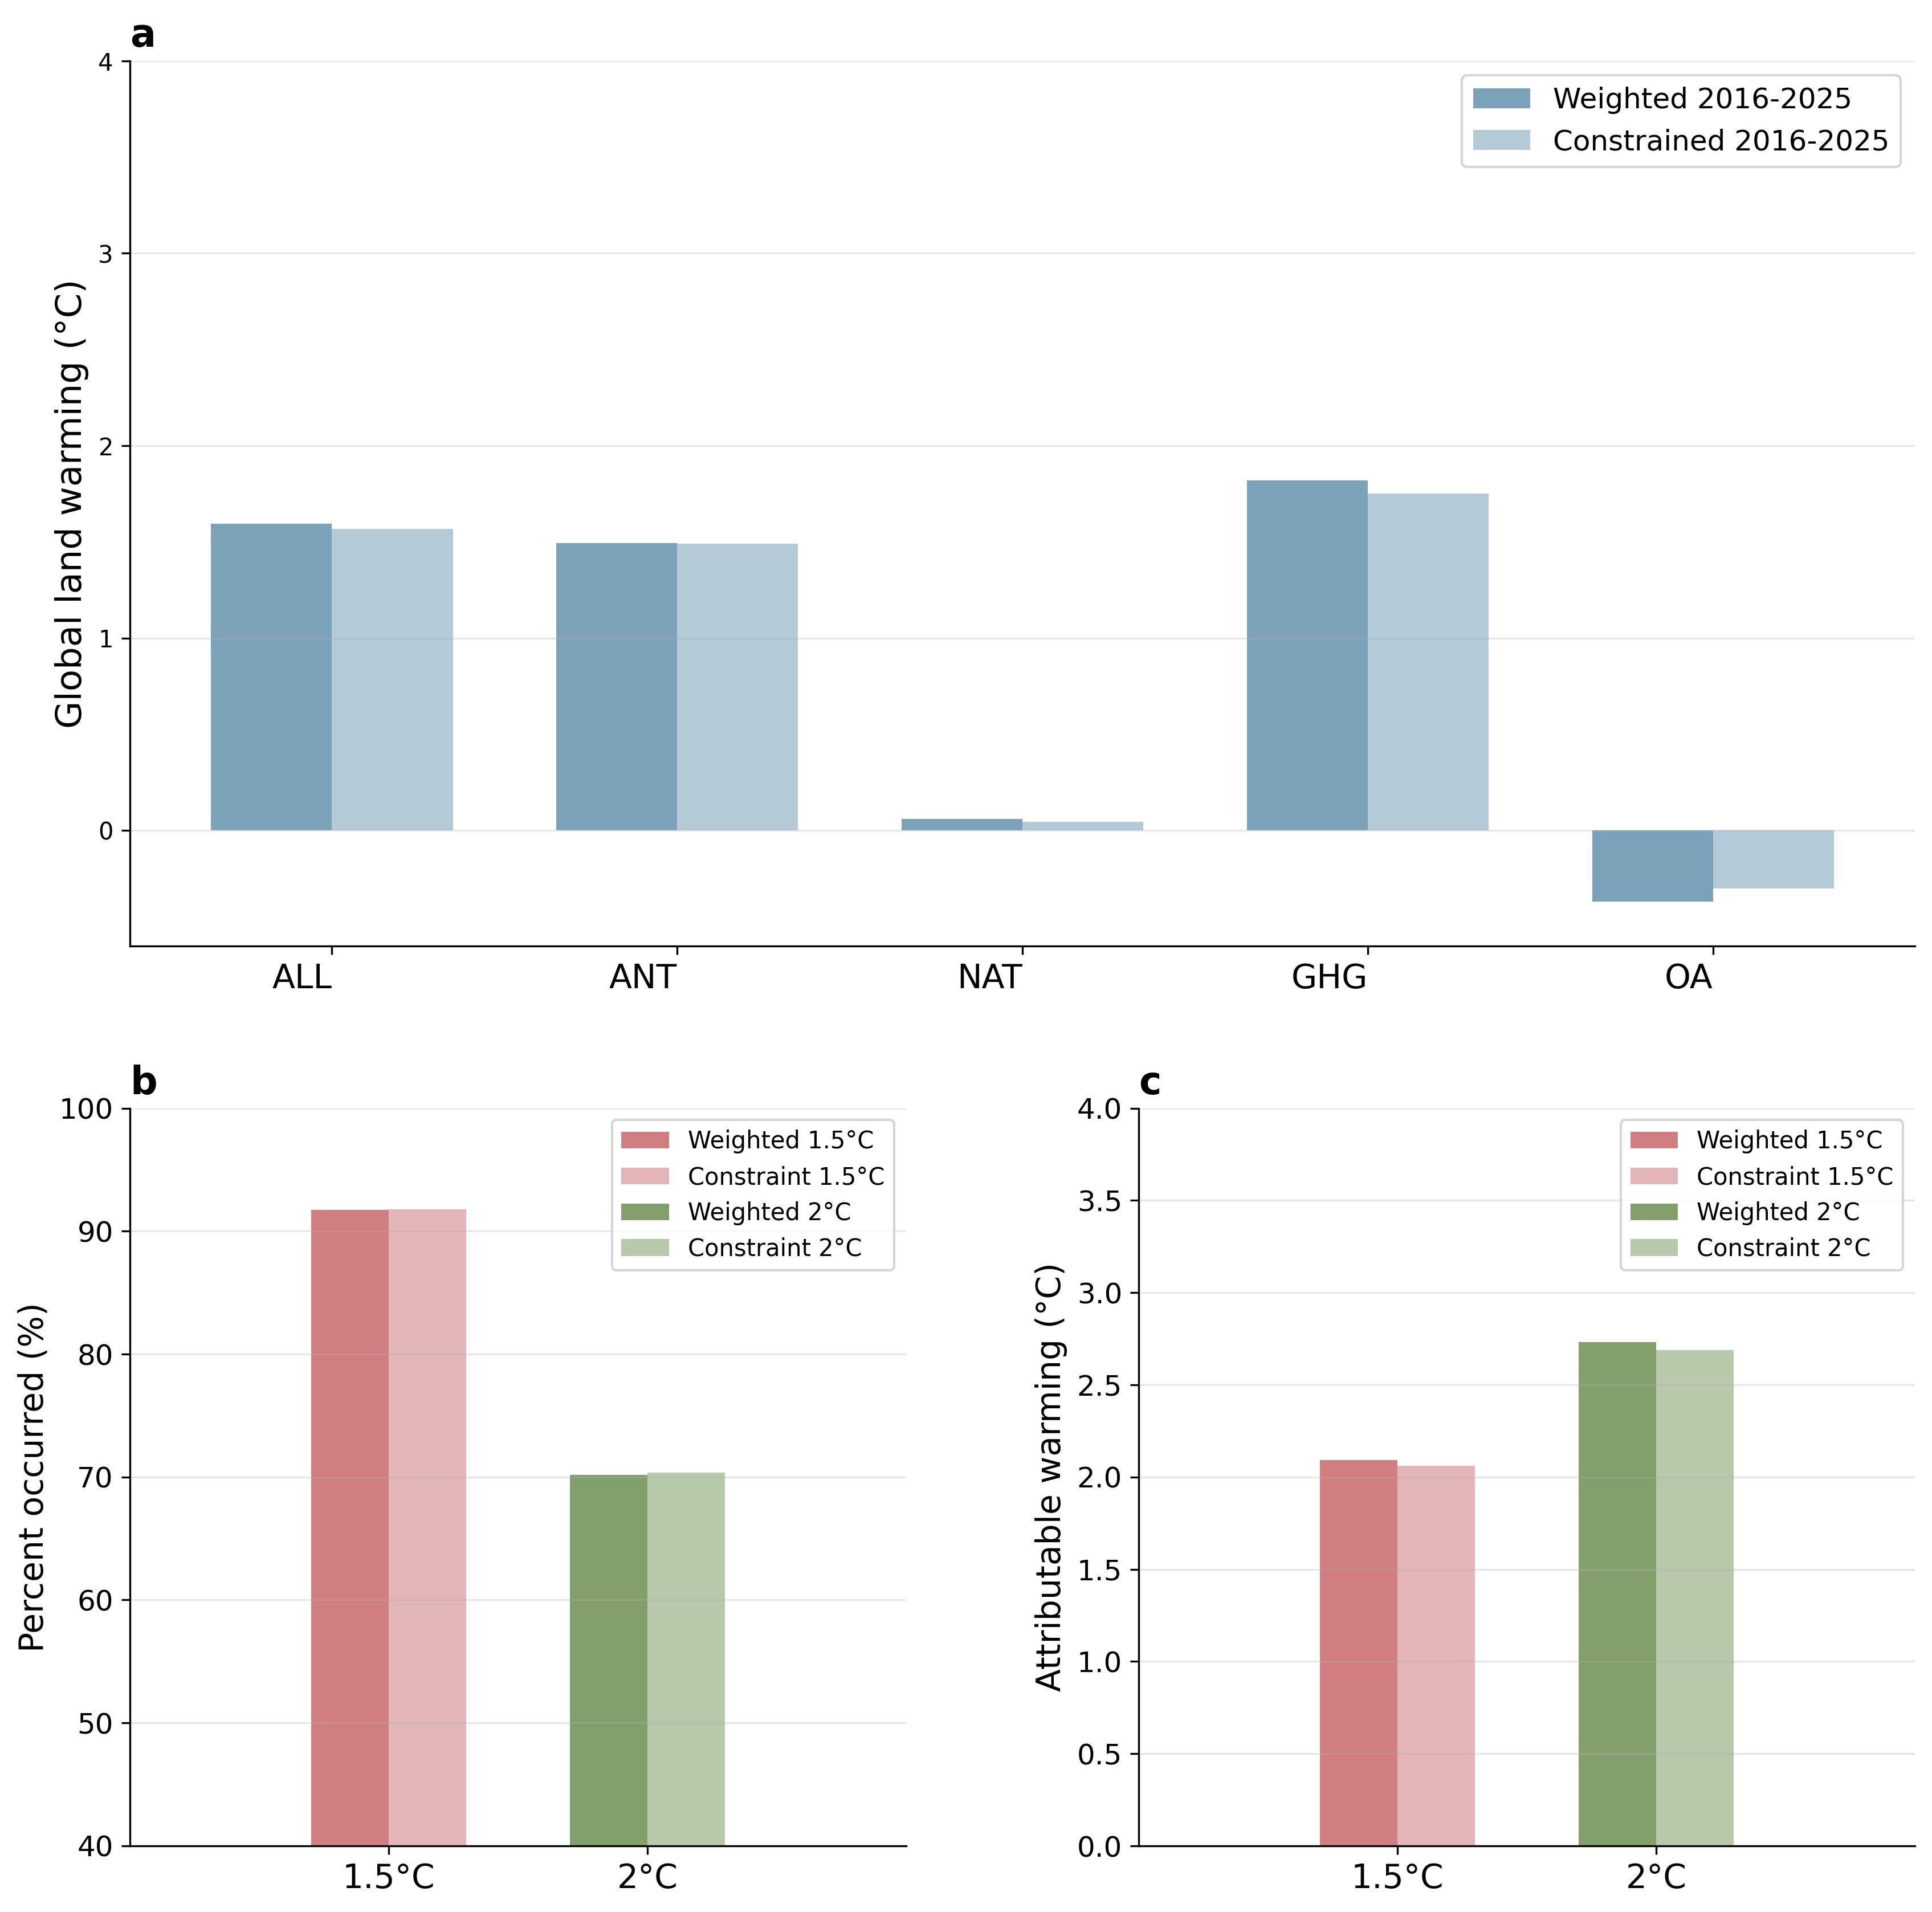

In [37]:
percent_data = {
    "Weighted 1.5°C": percent_reg_15_weighted_glob.values,
    "Constraint 1.5°C": percent_15_constraint_glob.values,
    "Weighted 2°C": percent_reg_2_weighted_glob.values,
    "Constraint 2°C": percent_2_constraint_glob.values,
}

warming_data = {
    "Weighted 1.5°C": warming_reg_15_weighted_glob.values,
    "Constraint 1.5°C": warming_15_constraint_glob.values,
    "Weighted 2°C": warming_reg_2_weighted_glob.values,
    "Constraint 2°C": warming_2_constraint_glob.values,
}
fig = plt.figure(figsize=(12, 12), dpi=300)

plot_global_plus_two_panels(
    global_constrained_warm,
    global_weighted_warm,
    forcings,
    percent_data,
    warming_data
)
fig.savefig('./saved_figures/ED_Fig10.pdf', dpi=300, bbox_inches='tight')
